# Function 4

This function is described by 4 input features, each of which is normalised to lie between 0 and 1. The optimisation goal is to maximise the output value. The function describes the estimated storage costs across warehouses for a business with high online sales. Accurate calculations are costly and only feasible fortnightly. Therefore, a machine learning model has been trained to estimate how far these costs deviate from an expensive baseline. The four input features are the hyperparameters of the machine learning model. The landscape is expected to be complicated with lots of local maxima. The initial data set consists of 30 points.

## Summary

All outputs in the initial data set are negative, implying that none of the configurations of input features they represent are better than the expensive baseline. The most promising method has been fitting a global quadratic linear regression model and submitting a query that aligns with its peak position. It is the only method that found a point with positive output value. Given that the landscape is expected to have lots of local maxima rather than a single peak, this could be an indication that this peak is dominant in the underlying function, and there may be complex structure elsewhere. However, given the limited number of data points, this dominant peak may be a result of sparse sampling and had another promising region been found, the model may have broken down. Finally, the assumption that there are many local maxima may be incorrect, but it is not possible to reach this conclusion with any degree of certainty given the limited data available.

The identification of other promising regions was attempted using neural network surrogate models, but ultimately they struggled. This may be because there are not enough data points available to train a neural network for exploration in sparsely populated areas.

## Week 1 - Initial exploration

In [1]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid, largest_gap_midpoints

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [2]:
X, y = get_current_weeks_points(function_id=4, week=1)

print(f"Mean = {y.mean()}")
print(f"Standard deviation = {y.std()}")

print(f"Minimum = {y.min()}")
quantiles = [0.25, 0.5, 0.75]
for quantile in quantiles:
    print(f"{quantile * 100}% quantile = {np.quantile(y, quantile)}")
print(f"Maximum = {y.max()}")

Mean = -17.23858735128667
Standard deviation = 7.01798521152638
Minimum = -32.625660215962455
25.0% quantile = -21.578590320775753
50.0% quantile = -16.040082439775908
75.0% quantile = -12.745905545432574
Maximum = -4.025542281908162


All initial output values are negative, and as this is a maximisation problem this implies that none of the observed data points are better than the expensive baseline. The values seem fairly well spread out, although the difference between the minimum and 25% quantile is a little larger than the other quantile intervals. This does not appear to have had a big impact on the mean as it lies reasonably close to the median.

The 2D projections below suggest a promising region around the data point with the highest output, even though the its output lies well below the expensive baseline. It also appears to lie closer to the middle of the features as opposed to any boundaries:

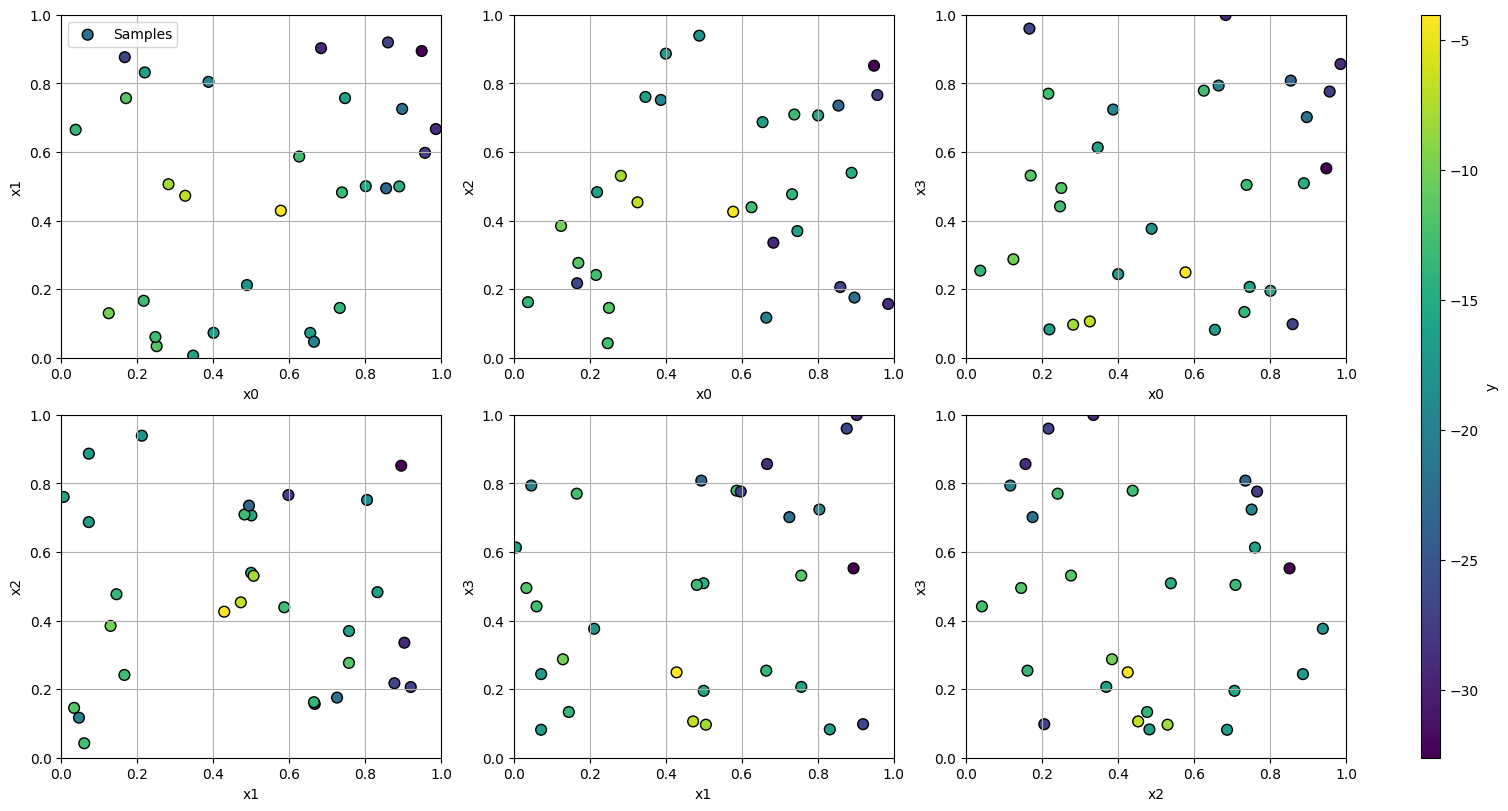

In [3]:
fig, axs = plot_2d_array(X, y)

As we expect many local maxima, we can assume that the landscape is jagged and can try to fit a Gaussian Process surrogate model with a Matern kernel and smoothness parameter `nu` = 1.5.

While we could query the area around the current candidate for the peak immediately, it still lies well below the expensive baseline and there may be a better candidate elsewhere. We can dedicate some queries to exploration.

In [4]:
# Fit Gaussian Process surrogate model on known data
kernel = Matern(length_scale=[0.05, 0.05, 0.05, 0.05], length_scale_bounds=(1e-3, 100), nu=1.5)
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([x_grid.ravel() for x_grid in X_grid])
y_mean, y_std = model.predict(X_pred, return_std=True)

# Use standard deviation as acquisition function for pure exploration
max_idx = np.argmax(y_std)
x_next = X_pred[max_idx]
print(f"Proposed point using pure exploration acquisition function = {x_next}")

Proposed point using pure exploration acquisition function = [1. 0. 1. 1.]


Using the maximum value of the standard deviation as the acquisition function for pure exploration we get a proposed point close to the boundary. This is perhaps not too surprising given that our grid resolution is quite poor having divided each dimension into 20 slices for memory reasons. Therefore, trying to find a point that lies on this grid and is the farthest from any corners or observed data points is going to tend towards at least one of the boundaries.

It may be better to use a different algorithm for exploration, where we find the largest empty space in each dimension, and use the midpoints of these spaces to propose a point to query next:

In [5]:
x_next = largest_gap_midpoints(X)
print(f"Proposed point from midpoints of largest empty spaces in each dimension = {x_next}")

Proposed point from midpoints of largest empty spaces in each dimension = [0.5331799  0.32036842 0.6132103  0.90816789]


This method assumes independence between dimensions, which may not be the case. However, as we are in the initial exploration phase, we can make this assumption for now and revisit it later.

## Week 2 - Further exploration

In [6]:
from bbo.data import get_current_weeks_points
from bbo.utils import largest_gap_midpoints

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [7]:
X, y = get_current_weeks_points(function_id=4, week=2)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.53318  0.320368 0.61321  0.908168] yields -16.279652224839257


Last week's query yields a value close to the median from the initial data set. As we are in a purely exploratory phase, this is not unexpected. Should we use a surrogate model in the future, results like this can help to identify areas that are unlikely to contain points that yield a high output.

Before the introduction of a surrogate model, we can improve our understanding of the domain by continuing to explore sparsely populated regions. Again, we assume that the input features are independent, which is a reasonable assumption to make at this stage given how little information we have:

In [8]:
x_next = largest_gap_midpoints(X)
print(f"Proposed point from midpoints of largest empty spaces in each dimension = {x_next}")

Proposed point from midpoints of largest empty spaces in each dimension = [0.44462961 0.37456987 0.80887583 0.33163391]


## Week 3 - More exploration

In [9]:
from bbo.data import get_current_weeks_points
from bbo.utils import largest_gap_midpoints

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [10]:
X, y = get_current_weeks_points(function_id=4, week=3)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.44463  0.37457  0.808876 0.331634] yields -10.106192759508605


Again, last week's query yields a relatively low output, but it is higher than our previous queries. The policy of exploration may be beginning to identify more promising regions, refining our understanding of the landscape.

As there are still large regions of the domain that are unexplored, and it appears as though we may be beginning to identify more promising regions, we can continue to explore this week:

In [11]:
x_next = largest_gap_midpoints(X)
print(f"Proposed point from midpoints of largest empty spaces in each dimension = {x_next}")

Proposed point from midpoints of largest empty spaces in each dimension = [0.081348   0.26616655 0.07948191 0.65735896]


## Week 4 - The quadratic linear regression model looks promising

In [12]:
import numpy as np

from bbo.data import get_current_weeks_points
from bbo.linear_regression import (
    get_lr_models,
    kfoldcv,
    loocv,
    get_hessian_matrix_and_gradient_vector,
)
from bbo.plotting import plot_2d_array, plot_correlation_matrix
from bbo.stats import get_baseline_rmse

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [13]:
X, y = get_current_weeks_points(function_id=4, week=4)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.081348 0.266167 0.079482 0.657359] yields -13.8176517024329


Another low output from last week's query. While exclusively focusing on exploration is helping to reduce uncertainty in sparsely populated regions, it is not helping to identify promising regions to exploit. It is a bit like shooting in the dark, and given the inefficiency in finding a maximum of continuing this, we should try to find a model that can explain the data.

We should try to explore around the current best observed point to see whether it actually is part of a peak:

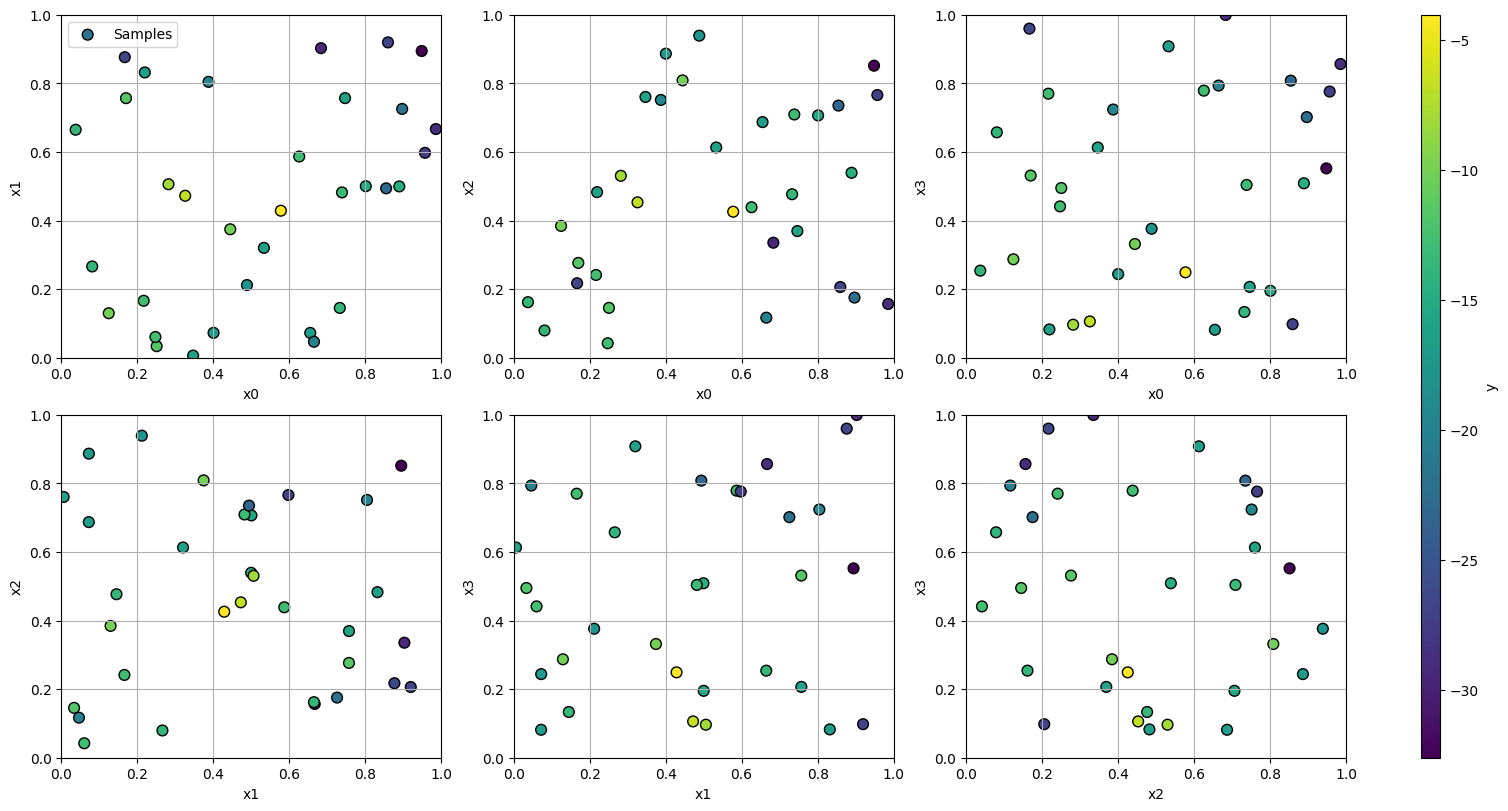

In [14]:
fig, axs = plot_2d_array(X, y)

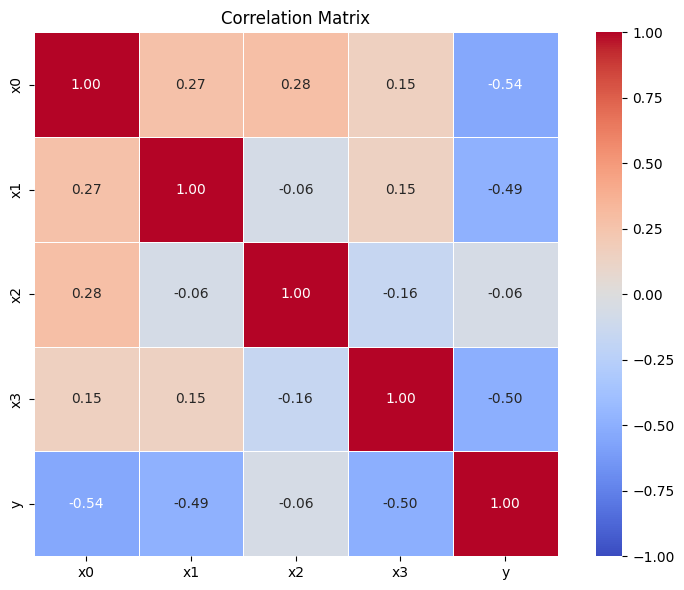

In [15]:
fig, ax = plot_correlation_matrix(X, y)

The correlation matrix shows some minor negative correlation between the output and features `x0`, `x1` and `x3`. There does not appear to be any evidence of correlation between features. We can try to fit a range of linear regression models:

In [16]:
print(f"Baseline RMSE = {get_baseline_rmse(y)}")

cv_methods = {
    "Leave One Out Cross Validation": loocv(X, y),
    "10-Fold Cross Validation": kfoldcv(X, y, seed_input=seed_input, n_splits=10),
}
for method, scores in cv_methods.items():
    print(f"\n{method}")
    for name, stats in scores.items():
        print(f"{name} model: RMSE = {stats['RMSE']}, RMSE spread = {stats['RMSE spread']}, relative RMSE = {stats['relative RMSE']}")

Baseline RMSE = 6.8247339250471

Leave One Out Cross Validation
linear model: RMSE = 5.2302711001934465, RMSE spread = 2.8474616287740346, relative RMSE = 0.18287585779377988
quadratic model: RMSE = 0.9644454296901949, RMSE spread = 0.647935170902796, relative RMSE = 0.033721729117131546
cubic model: RMSE = 3.0692042157183974, RMSE spread = 2.465521677050896, relative RMSE = 0.1073143901992055

10-Fold Cross Validation
linear model: RMSE = 5.550527360506521, RMSE spread = 0.4203872867825417, relative RMSE = 0.194073582958813
quadratic model: RMSE = 1.1271299708612956, RMSE spread = 0.29733868075312764, relative RMSE = 0.03940997633157368
cubic model: RMSE = 4.2499618032993185, RMSE spread = 0.5123676525866526, relative RMSE = 0.14859945029243635


The quadratic linear regression model seems to be a good fit to the data. Both leave one out and 10-fold cross validations give similar Root Mean Square Error (RMSE) estimates, which are significantly smaller than the baseline RMSE calculated assuming all observed points are predicted to yield an output equal to the mean. It appears as though the linear model may be underfitting and the cubic model is too complicated.

However, this result should be treated with some caution. The data set is relatively small, and in the absence of other promising areas the model may be overfitting. The discovery of another promising area could cause the model to break down.

The quadratic model will have one stationary point. We can extract the Hessian matrix to determine whether this point is a maximum, minimum or saddle:

In [17]:
lr_models = get_lr_models()
lr_model = lr_models["quadratic"]
lr_model.fit(X, y)

H, g = get_hessian_matrix_and_gradient_vector(
    model=lr_model, n_dimensions=n_dimensions
)
print("Hessian matrix for quadratic linear regression model:")
print(H)

Hessian matrix for quadratic linear regression model:
[[-77.7850291    2.20738652   2.57635424   1.39426573]
 [  2.20738652 -76.50891291  -0.57694524   1.8934039 ]
 [  2.57635424  -0.57694524 -74.98639058  -1.93436953]
 [  1.39426573   1.8934039   -1.93436953 -71.99311263]]


The eigenvalues of the matrix are all negative, indicating that the stationary point is a maxima. The off-diagonal terms (mixed partial derivatives) are small relative to the diagonal terms, indicating that the features do not strongly interact locally. The relatively large magnitudes of the eigenvalues indicate that the peak is quite sharp according to the model.

The relatively small off-diagonal terms in the Hessian matrix indicate that there is little interaction between features. This is consistent with what we see in the correlation matrix.

It is interesting how a global linear regression model seems to fit the data quite well, even though we expect there to be many maxima. The peak suggested by the model appears to lie quite far from any known points in a relatively unexplored region, making it a very strong candidate for this week's query. Querying this point also helps us to test whether the global quadratic model has merit or is an artefact of limited data.

In [18]:
# Find stationary point (i.e. where gradient = 0)
x_next = -np.linalg.solve(H, g)
print(f"Proposed point as peak of quadratic linear regression model = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")

Proposed point as peak of quadratic linear regression model = [0.39159941 0.39265982 0.38226008 0.3882805 ]
Distance of proposed point from nearest neighbour = 0.23928414063538953


## Week 5 - A new maximum from the global quadratic linear regression model

In [19]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.linear_regression import (
    get_lr_models,
    kfoldcv,
    loocv,
    get_hessian_matrix_and_gradient_vector,
)
from bbo.plotting import plot_2d_array
from bbo.utils import grid_search

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [20]:
X, y = get_current_weeks_points(function_id=4, week=5)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.391599 0.39266  0.38226  0.388281] yields -0.07555966523370428


Last week's query gives an output that is extremely close to the expensive baseline. This is a massive improvement and may indicate that the underlying function has a dominant global structure that can be modelled by a quadratic form. The other maxima that we expect may be much smaller pertubations in the landscape.

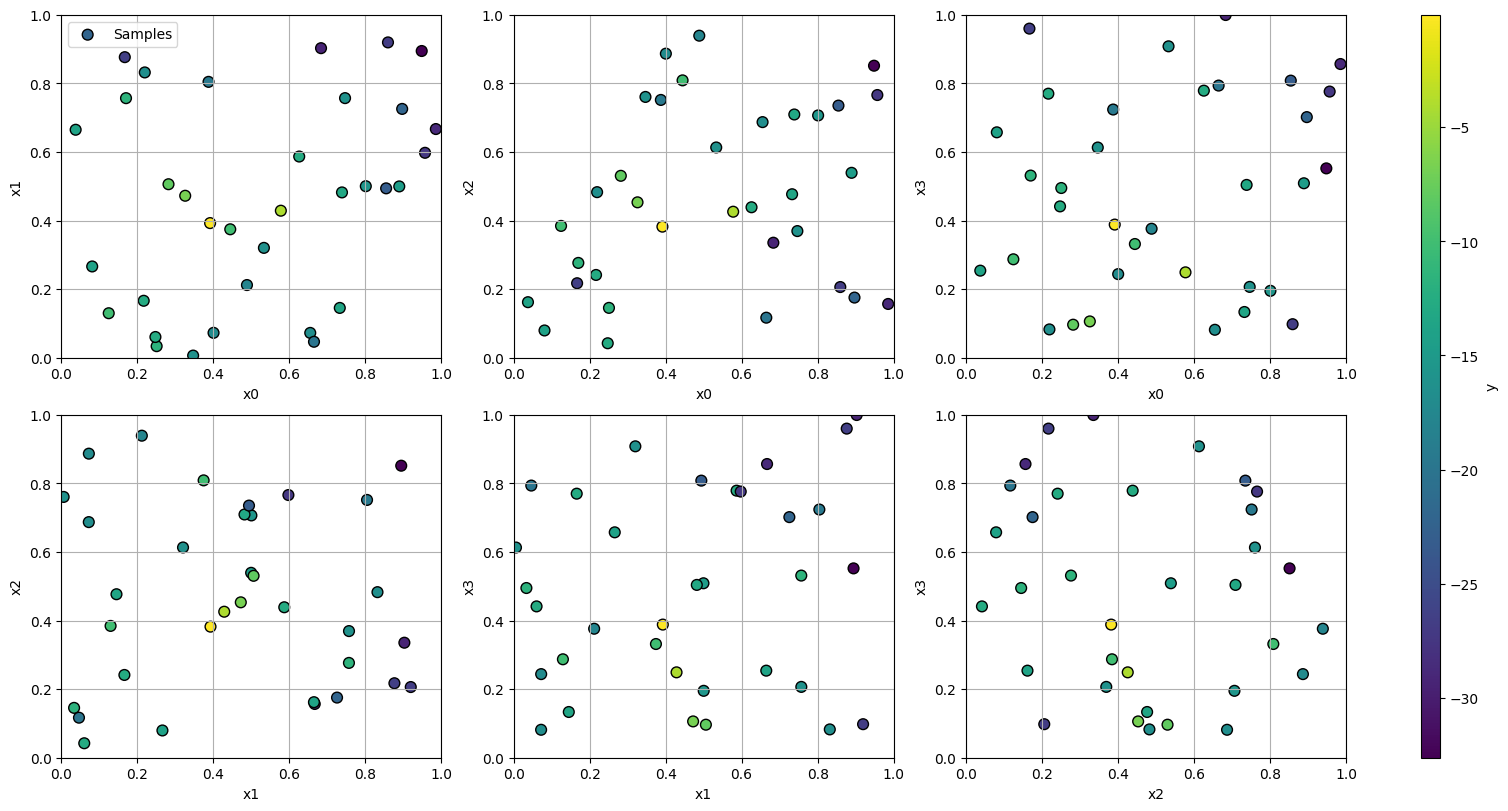

In [21]:
fig, axs = plot_2d_array(X, y)

In [22]:
lr_models = get_lr_models()
lr_model = lr_models["quadratic"]
lr_model.fit(X, y)

H, g = get_hessian_matrix_and_gradient_vector(
    model=lr_model, n_dimensions=n_dimensions
)

# Find stationary point (i.e. where gradient = 0)
x_next = -np.linalg.solve(H, g)
print(f"Proposed point as peak of quadratic linear regression model = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")

Proposed point as peak of quadratic linear regression model = [0.39946284 0.39754491 0.37820458 0.39496873]
Distance of proposed point from nearest neighbour = 0.012119176217975527


After fitting the quadratic linear regression model to the updated data, it predicts that the maximum lies very close to an observed data point. As we suspect that there are other local maxima, a global quadratic linear regression model may be too simple to describe the underlying function. We have a limited number of queries left, which should be used to search for other maxima rather than exploiting this peak. We think we are close to a local maximum, so if we do not have success in finding other maxima, we can always revisit this proposed point with our last query.

We can go back to Bayesian Optimisation with a Gaussian Process surrogate model to allow for non-parametric, flexible modelling of the landscape. We can maximise the Upper Confidence Bound (UCB) acquisition function with a relatively high exploration parameter to find the next point in a region of high uncertainty. Given the relatively poor resolution of the grid, we can define the grid and perform a grid search. Then we can zoom-in to the point that yields the highest UCB value and construct a new grid around it at a higher resolution. We can repeat this process until we reach a resolution of around 1e-6, which is equivalent to the maximum number of decimal places that can be given to the inputs when submitting queries.

The disadvantage with this technique is that better regions may be masked by the poor resolution of the initial grid.

In [23]:
# Fit Gaussian Process surrogate model with RBF kernel on known data
# Length scales are initially set to 0.1 in both dimensions
model = get_reg_model(
    n_dimensions=4, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: {length_scales}")

# Use UCB acquisition function with k = 1.96 to find next point
x_next = grid_search(
    model=model,
    acq_func=acquisition.ucb,
    n_dimensions=n_dimensions,
    grd_res=grd_res,
    k=1.96,
)
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")

Length scales: [0.53335427 0.49516538 0.57816982 0.49505706]
Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.45268573 0.45268573 0.30268573 0.45268573]
Distance of proposed point from nearest neighbour = 0.13347176279472836


The proposed point lies significantly far away from its nearest neighbour, so we can submit it as the next query.

On a side note, during the original analysis, I mistakenly did not set the random state of the Gaussian Process surrogate model, and therefore the UCB acquisition function suggested a different point to query: (0.435532, 0.474614, 0.315902, 0.442383). It is this second point that was queried. However, this point does not lie far from the suggested point above, and therefore is expected to provide similar information.

## Week 6 - Investigating the quadratic linear regression model

In [24]:
import numpy as np

from bbo.data import get_current_weeks_points
from bbo.linear_regression import (
    get_lr_models,
    kfoldcv,
    loocv,
    get_hessian_matrix_and_gradient_vector,
)
from bbo.plotting import plot_2d_array
from bbo.stats import get_baseline_rmse

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [25]:
X, y = get_current_weeks_points(function_id=4, week=6)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.435532 0.474614 0.315902 0.442383] yields -1.340753744492012


Not as high as the previous week, but encouraging nonetheless as the output from last week's query is significantly higher than that from any of the initial data points.

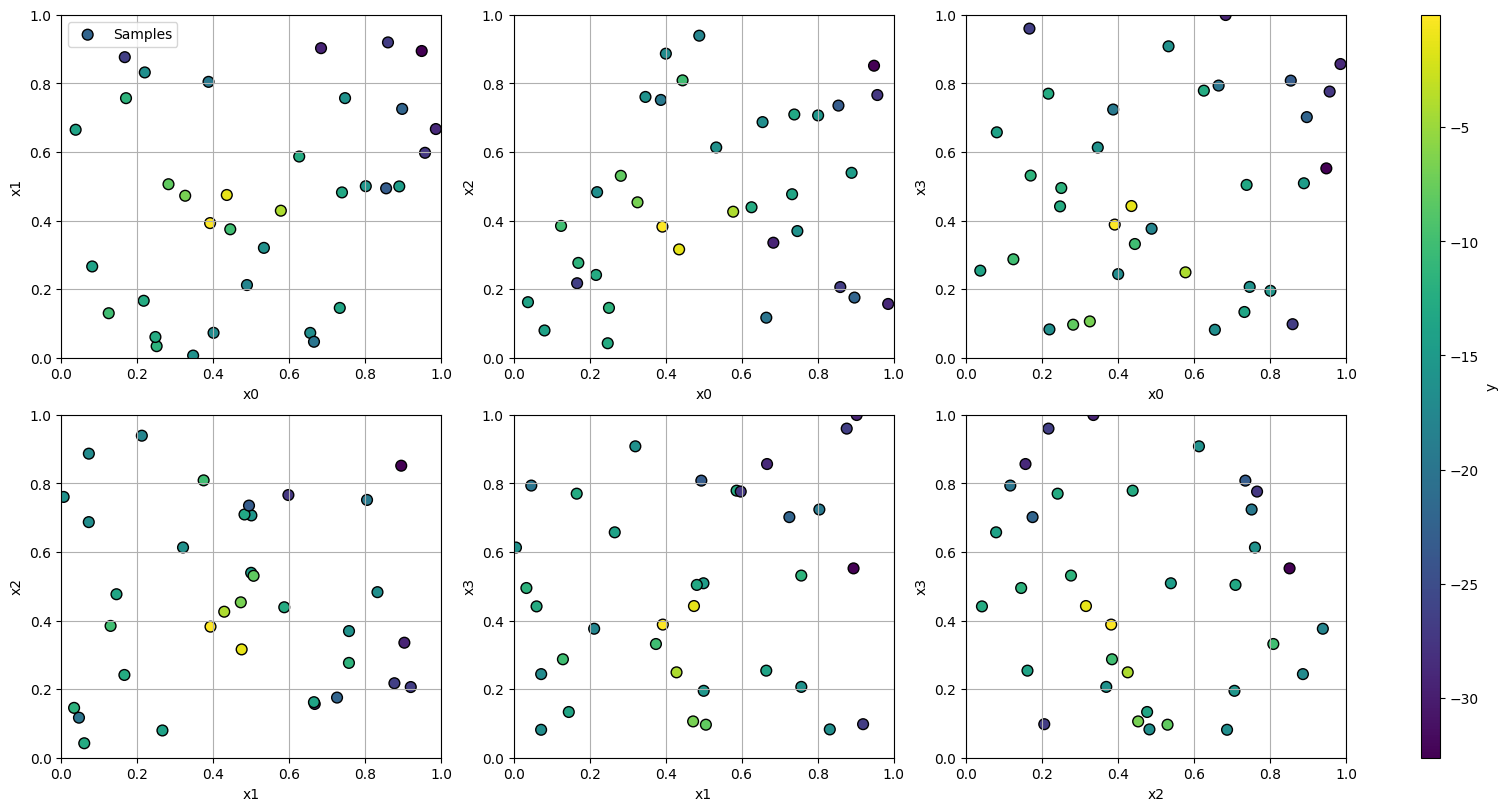

In [26]:
fig, axs = plot_2d_array(X, y)

The two observed data points that yield the highest outputs lies close to each other in all planes. It is possible that they are part of the same local maximum.

It would be interesting to see what effect the discovery of this promising region has on the global linear regression models:

In [27]:
print(f"Baseline RMSE = {get_baseline_rmse(y)}")

cv_methods = {
    "Leave One Out Cross Validation": loocv(X, y),
    "10-Fold Cross Validation": kfoldcv(X, y, seed_input=seed_input, n_splits=10),
}
for method, scores in cv_methods.items():
    print(f"\n{method}")
    for name, stats in scores.items():
        print(f"{name} model: RMSE = {stats['RMSE']}, RMSE spread = {stats['RMSE spread']}, relative RMSE = {stats['relative RMSE']}")

Baseline RMSE = 7.618779168525893

Leave One Out Cross Validation
linear model: RMSE = 6.1955418334790755, RMSE spread = 3.486000762987253, relative RMSE = 0.19033863885684268
quadratic model: RMSE = 1.370486960880829, RMSE spread = 0.8717101385708064, relative RMSE = 0.04210392403381211
cubic model: RMSE = 6.52105624724262, RMSE spread = 4.425912735126956, relative RMSE = 0.2003390507835658

10-Fold Cross Validation
linear model: RMSE = 6.48821818701349, RMSE spread = 0.4451294365252975, relative RMSE = 0.19933020412338567
quadratic model: RMSE = 1.567118345797655, RMSE spread = 0.31185819239492185, relative RMSE = 0.04814480813524152
cubic model: RMSE = 3.4035539493760107, RMSE spread = 0.46020265789687953, relative RMSE = 0.10456354640353976


The Root Mean Square Error (RMSE) has increased a little bit for the quadratic linear regression model, as has the baseline RMSE. Still both cross validations give similiar RMSE estimates for the quadratic linear regression model, and those estimates are significantly better than the baseline RMSE. As a reminder, the baseline RMSE has been calculated by asusming that the predicted output of every point is equal to the mean output.

In [28]:
lr_models = get_lr_models()
lr_model = lr_models["quadratic"]
lr_model.fit(X, y)

H, g = get_hessian_matrix_and_gradient_vector(
    model=lr_model, n_dimensions=n_dimensions
)

# Find stationary point (i.e. where gradient = 0)
x_next = -np.linalg.solve(H, g)
print(f"Proposed point as peak of quadratic linear regression model = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")

Proposed point as peak of quadratic linear regression model = [0.4051739  0.4020415  0.37267045 0.39844367]
Distance of proposed point from nearest neighbour = 0.021622436451081445


The peak position proposed by the quadratic linear regression model has moved a bit farther away from its neighbour, but is still in its vicinity.

In [29]:
# Find eigenvalues and eigenvectors of Hessian matrix
eigenvalues, eigenvectors = np.linalg.eigh(H)

idx = np.argsort(np.abs(eigenvalues))

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"Eigenvalues of Hessian matrix of quadratic linear regression model = {eigenvalues}")

Eigenvalues of Hessian matrix of quadratic linear regression model = [-75.29191364 -78.58218053 -83.07647208 -92.86767476]


The eigenvalues are all negative, which indicates that the stationary point is a peak. Eigenvalues indicate the curvature of the peak in each direction, and as the spread is relatively small (around 25%), we can conclude that the model believes the peak to be fairly round and there is no extremely flat direction. We can take a look at the contributions of each feature in the flattest direction (lowest eigenvalue) by looking at the corresponding eigenvectors:

In [30]:
print(f"Eigenvector corresponding to flattest direction = {eigenvectors[:, 0]}")

Eigenvector corresponding to flattest direction = [ 0.06248907  0.69973158 -0.51900459  0.48693436]


The eigenvector describes the direction of minimal curvature. If we move along this direction (or in the opposite direction) we can explore the flattest direction from the current peak. This can help us to determine whether the local maximum is well-defined. A relatively large step size of 0.35 is chosen to move beyond the neighbourhood of the current best point. It should be noted that this choice is arbitrary and not derived from the model. We have two possible candidates for the next query:

In [31]:
max_idx = np.argmax(y)
best_point = X[max_idx]
delta = 0.35  # step size
v = eigenvectors[:, 0]
x_plus = best_point + delta * v  # along eigenvector direction
x_minus = best_point - delta * v  # opposite direction

print(f"Proposed point along eigenvector direction = {x_plus}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_plus, axis=1))}\n")
print(f"Proposed point in opposite direction = {x_minus}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_minus, axis=1))}")

Proposed point along eigenvector direction = [0.41347017 0.63756605 0.20060839 0.55870802]
Distance of proposed point from nearest neighbour = 0.2320866709573898

Proposed point in opposite direction = [0.36972783 0.14775395 0.56391161 0.21785398]
Distance of proposed point from nearest neighbour = 0.3119200817385587


As the proposed point in the opposite direction lies farther away from any observed data points, we should query this next.

## Week 7 - Looking in the opposite direction

In [32]:
import numpy as np

from bbo.data import get_current_weeks_points
from bbo.linear_regression import (
    get_lr_models,
    kfoldcv,
    loocv,
    get_hessian_matrix_and_gradient_vector,
)
from bbo.plotting import plot_2d_array
from bbo.stats import get_baseline_rmse

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [33]:
X, y = get_current_weeks_points(function_id=4, week=7)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.369728 0.147754 0.563912 0.217854] yields -7.979548504888754


Last week's query yields a significantly worse output than that from the best observed point. This provides evidence that the best observed point lies close to a local maximum as moving in one direction results in a significant drop in output value. The quadratic linear regression model appears to do a good job of describing this peak. We can take a look along the eigenvector direction (corresponding to the opposite direction to last week's query) to confirm this.

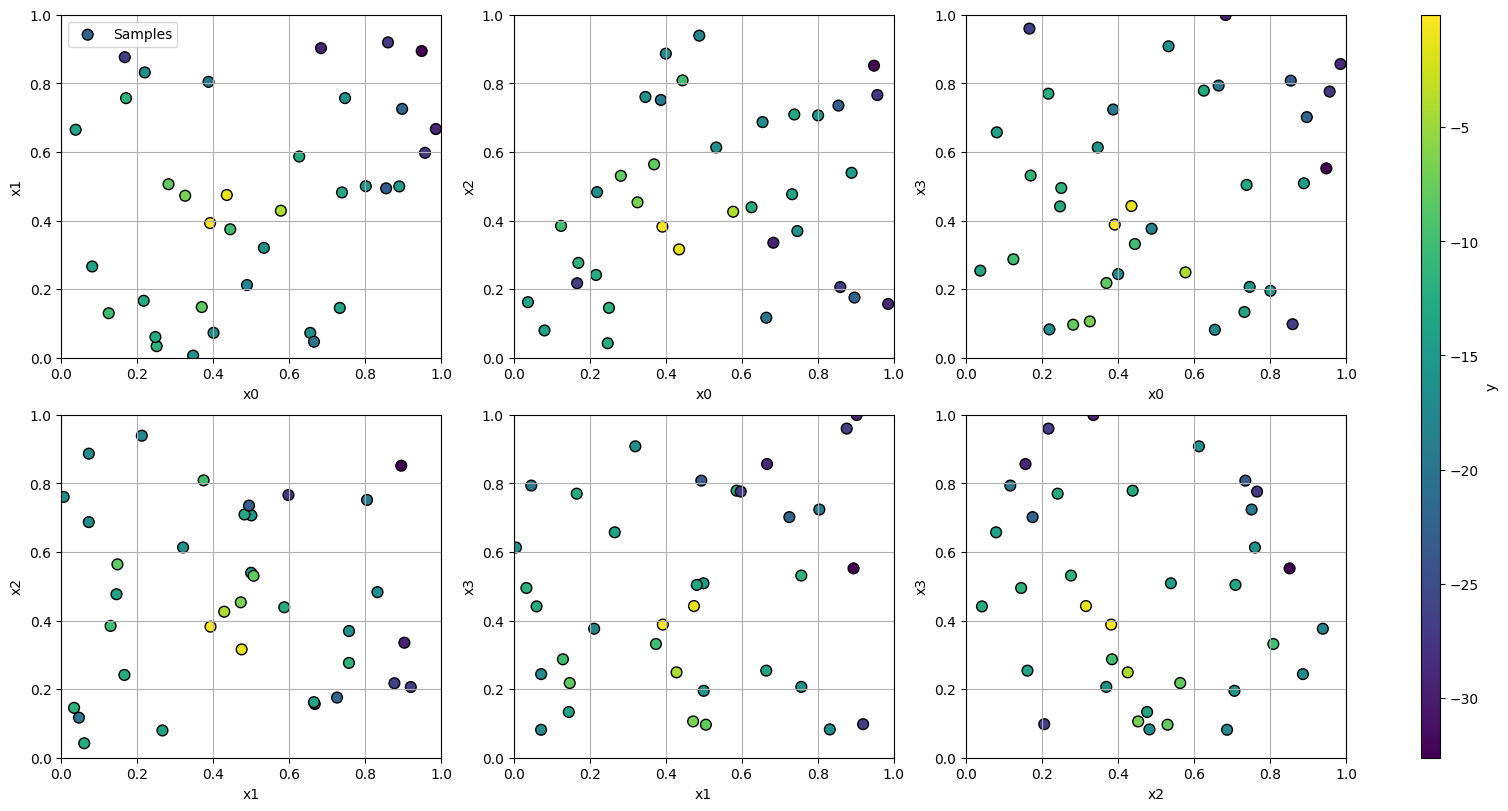

In [34]:
fig, axs = plot_2d_array(X, y)

In [35]:
print(f"Baseline RMSE = {get_baseline_rmse(y)}")

cv_methods = {
    "Leave One Out Cross Validation": loocv(X, y),
    "10-Fold Cross Validation": kfoldcv(X, y, seed_input=seed_input, n_splits=10),
}
for method, scores in cv_methods.items():
    print(f"\n{method}")
    for name, stats in scores.items():
        print(f"{name} model: RMSE = {stats['RMSE']}, RMSE spread = {stats['RMSE spread']}, relative RMSE = {stats['relative RMSE']}")

Baseline RMSE = 7.625979093614606

Leave One Out Cross Validation
linear model: RMSE = 6.104621236522748, RMSE spread = 3.472714520387627, relative RMSE = 0.18754538797841208
quadratic model: RMSE = 1.3204276849098908, RMSE spread = 0.8417684824727609, relative RMSE = 0.04056600939994111
cubic model: RMSE = 39.880809857419585, RMSE spread = 38.191305512842746, relative RMSE = 1.2252131078755366

10-Fold Cross Validation
linear model: RMSE = 6.239542507024658, RMSE spread = 0.3912213576841763, relative RMSE = 0.19169042188672944
quadratic model: RMSE = 1.4958423034598038, RMSE spread = 0.34215402867563993, relative RMSE = 0.04595507473559292
cubic model: RMSE = 4.510526773573611, RMSE spread = 0.6499114392639965, relative RMSE = 0.13857182304380397


The quadratic linear regression model still performs well, comfortably beating the baseline RMSE estimate.

In [36]:
lr_models = get_lr_models()
lr_model = lr_models["quadratic"]
lr_model.fit(X, y)

H, g = get_hessian_matrix_and_gradient_vector(
    model=lr_model, n_dimensions=n_dimensions
)

# Find stationary point (i.e. where gradient = 0)
x_next = -np.linalg.solve(H, g)
print(f"Proposed point as peak of quadratic linear regression model = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")

Proposed point as peak of quadratic linear regression model = [0.40557663 0.40307539 0.3713876  0.39883059]
Distance of proposed point from nearest neighbour = 0.023094529158871856


Although the proposed peak from the quadratic linear regression model has moved a little farther away from the best observed point, it is still quite close. It probably is not worth querying at the moment. We can save it for the final query if we do not find any other local maxima.

In [37]:
# Find eigenvalues and eigenvectors of Hessian matrix
eigenvalues, eigenvectors = np.linalg.eigh(H)

idx = np.argsort(np.abs(eigenvalues))

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"Eigenvalues of Hessian matrix of quadratic linear regression model = {eigenvalues}")
print(f"Eigenvectors corresponding to flattest direction = {eigenvectors[:, 0]}\n")

# Find next points to query
max_idx = np.argmax(y)
best_point = X[max_idx]
delta = 0.35  # should be good enough to escape from basin
v = eigenvectors[:, 0]
x_plus = best_point + delta * v  # along eigenvector direction
x_minus = best_point - delta * v  # opposite direction

print(f"Proposed point along eigenvector direction = {x_plus}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_plus, axis=1))}\n")
print(f"Proposed point in opposite direction = {x_minus}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_minus, axis=1))}")

Eigenvalues of Hessian matrix of quadratic linear regression model = [-75.2754782  -78.27864976 -82.91295819 -92.64111877]
Eigenvectors corresponding to flattest direction = [-0.00291289  0.63268006 -0.62406228  0.45853432]

Proposed point along eigenvector direction = [0.39057949 0.61409802 0.1638382  0.54876801]
Distance of proposed point from nearest neighbour = 0.23646921653236255

Proposed point in opposite direction = [0.39261851 0.17122198 0.6006818  0.22779399]
Distance of proposed point from nearest neighbour = 0.05025478195544819


If we move along the eigenvector direction and see a similar drop in output, we strengthen our suspicion that the observed point with the highest output is very close to the local maximum.

It should be noted that this analysis is based on the geometry of the quadratic model. It may not translate to the geometry of the underlying function.

## Week 8 - A return to Bayesian Optimisation

In [38]:
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.linear_regression import (
    get_lr_models,
    kfoldcv,
    loocv,
    get_hessian_matrix_and_gradient_vector,
)
from bbo.plotting import plot_2d_array
from bbo.random import create_rng_seed
from bbo.stats import get_baseline_rmse
from bbo.utils import construct_meshgrid

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [39]:
X, y = get_current_weeks_points(function_id=4, week=8)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.390579 0.614098 0.163838 0.548768] yields -7.76202617004125


Moving from the current best point, both along the flattest direction and in the opposite direction yield similar outputs. This heavily implies that the best observed point lies close to the local maximum.

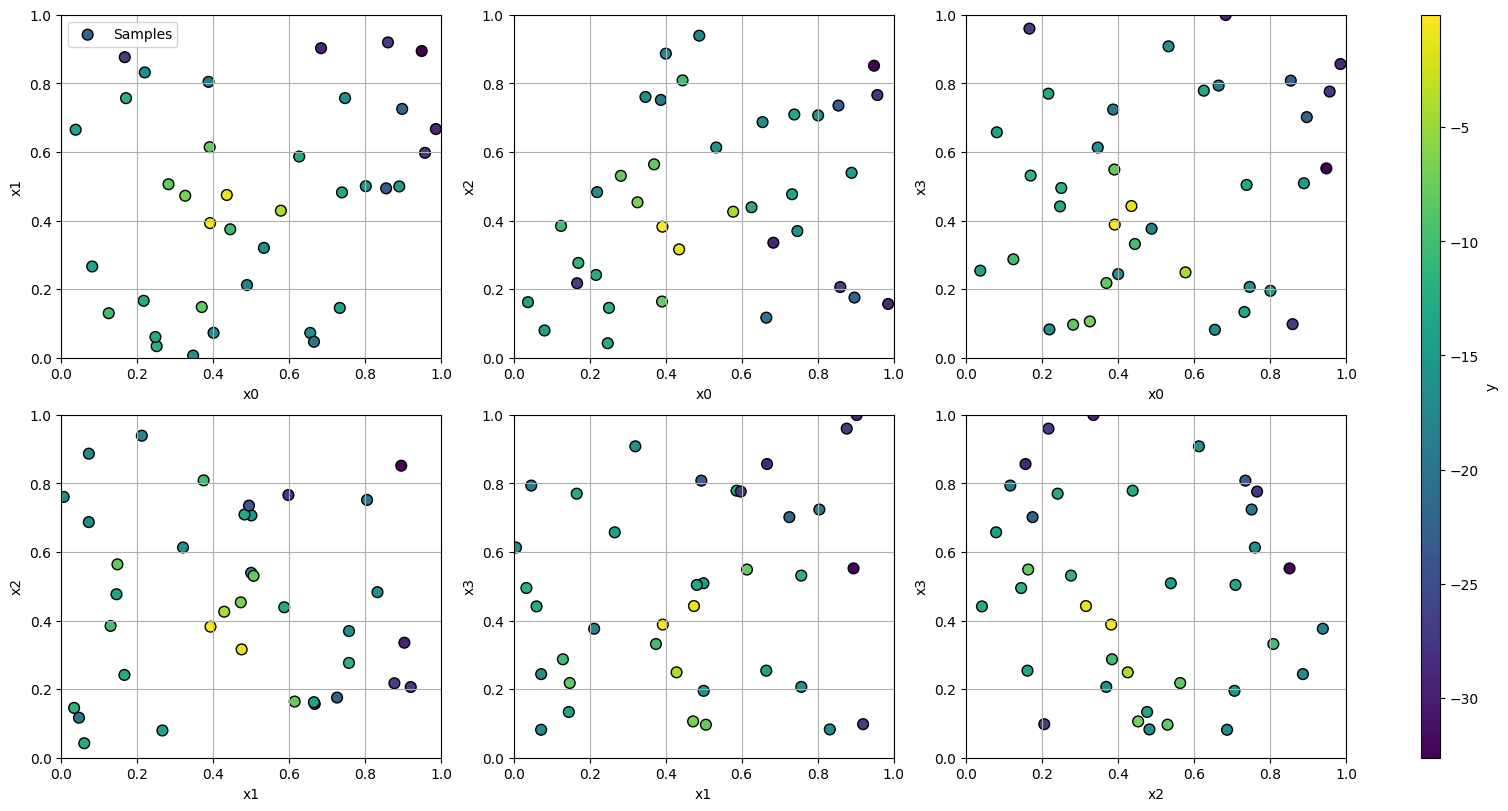

In [40]:
fig, axs = plot_2d_array(X, y)

In [41]:
print(f"Baseline RMSE = {get_baseline_rmse(y)}")

cv_methods = {
    "Leave One Out Cross Validation": loocv(X, y),
    "10-Fold Cross Validation": kfoldcv(X, y, seed_input=seed_input, n_splits=10),
}
for method, scores in cv_methods.items():
    print(f"\n{method}")
    for name, stats in scores.items():
        print(f"{name} model: RMSE = {stats['RMSE']}, RMSE spread = {stats['RMSE spread']}, relative RMSE = {stats['relative RMSE']}")

Baseline RMSE = 7.632750136474217

Leave One Out Cross Validation
linear model: RMSE = 6.207688638480902, RMSE spread = 3.4946561612572995, relative RMSE = 0.19071181143684426
quadratic model: RMSE = 1.2823135602427622, RMSE spread = 0.8208829750538973, relative RMSE = 0.03939507216711357
cubic model: RMSE = 3.7888943784887, RMSE spread = 3.2653624536277093, relative RMSE = 0.11640192547435532

10-Fold Cross Validation
linear model: RMSE = 6.187319118404316, RMSE spread = 0.4033138533310939, relative RMSE = 0.19008602166255953
quadratic model: RMSE = 1.3394120460537347, RMSE spread = 0.2739470472992416, relative RMSE = 0.041149244499760755
cubic model: RMSE = 6.644536565182525, RMSE spread = 0.6852899525010605, relative RMSE = 0.20413259721969626


The quadratic linear regression model still performs well, easily beating the baseline RMSE.

As we feel fairly confident that the best observed data point is close to a local maximum, which seems to be well described by a global linear regression model, we also believe that there are other local maxima. So, we can go back to Bayesian Optimisation and fit a Gaussian Process surrogate model to the data to find another point using an acquisition function. Now that we have the Hessian matrix from our quadratic linear regression model, we can fix the length scales to the inverse root of the diagonal values of this matrix. As the off-diagonal terms are small relative to the diagonal terms, the latter are a good approximation of the curvature. While fixing the length scales limits flexibility and we are applying local curvature globally, it provides a practical way to set non-uniform length scales. We should stick with a Matern kernel with smoothness parameter nu = 1.5 as we are not expecting the peaks to be as smooth as those we would see from a Radial Basis Function (RBF) kernel.

Searching the entire space is not productive, especially given the poor grid resolution available in 4 dimensions because of memory restrictions and the curse of dimensionality. Rather than search the entire domain, we can restrict the search to the neighbourhood of the best observed point. We can set bounds around the best observed data point of plus-or-minus 0.35 in each dimension. This should be large enough to move out of the local basin but small enough to stay within the same neighbourhood as the peak. The distance threshold of 0.25 ensures that only points that are sufficiently far from the best observed point are considered to encourage the discovery of other maxima. Another peak is unlikely to be very close to an observed data point, so we can add a term to the acquisition function to penalise grid points according to the distance to their nearest neighbour. We can scale this parameter to balance exploration and exploitation. We will use an Upper Confidence Bound (UCB) acquisition function with exploration parameter k = 1.96 in order as we have moved back into an exploratory phase. It is important that we normalise the UCB and the Euclidean distance terms in the acquisition function so that they are comparable.

In [42]:
# Fit to quadratic linear regression model
lr_models = get_lr_models()
lr_model = lr_models["quadratic"]
lr_model.fit(X, y)

H, g = get_hessian_matrix_and_gradient_vector(
    model=lr_model, n_dimensions=n_dimensions
)

# Find approximate curvatures of Hessian matrix in order of corresponding feature
curvatures = np.diag(H)

# Fix length scales to inverse root of Hessian eigenvalues
length_scales = 1 / np.sqrt(np.abs(curvatures))
kernel = Matern(length_scale=length_scales, length_scale_bounds='fixed', nu=1.5)
model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=create_rng_seed(seed_input),
)

# Set bounds around best point for grid search
max_idx = np.argmax(y)
best_point = X[max_idx]
delta = 0.35
bounds = np.clip(
    np.stack([best_point - delta, best_point + delta], axis=1), 0, 1
)

# Construct grid
X_grid = construct_meshgrid(
    n_dimensions=n_dimensions, grd_res=grd_res, bounds=bounds
)
X_pred = np.column_stack([X_.ravel() for X_ in X_grid])

# Ensure points on grid are a minimum distance away from best point
dist = cdist(X_pred, best_point[None, :])
mask = dist[:, 0] > 0.25  # minimum Euclidean distance
X_pred = X_pred[mask]

# Get predictions from model
y_mean, y_std = model.predict(X_pred, return_std=True)

# Build Upper Confidence Bound (UCB) acquisition function with term for
# penalising points close to existing samples
ucb_acq = acquisition.ucb(y_mean, y_std, k=1.96)
# Normalise output from UCB acqusition function
ucb_norm = (ucb_acq - ucb_acq.min()) / (ucb_acq.max() - ucb_acq.min() + 1e-12)
# For each candidate point calculate distance to nearest sampled neighbour and
# normalise
dist_neighbour = cdist(X_pred, X)
min_dist = np.min(dist_neighbour, axis=1)
min_dist_norm = (min_dist - min_dist.min()) / (min_dist.max() - min_dist.min() + 1e-12)
beta = 0.4  # distance weighting parameter
acq = ucb_norm + beta * min_dist_norm

max_idx = np.argmax(acq)
x_next = X_pred[max_idx]
print(f"Proposed point using UCB acquisition function with distance penalty = {x_next}")

Proposed point using UCB acquisition function with distance penalty = [0.041599 0.42766  0.66226  0.668281]


The proposed point above differs from the one that was submitted as there was a major mistake in the analysis that has been corrected here. When extracting the eigenvalues of the Hessian matrix, they were sorted into ascending order, breaking their correspondence with their associated eigenvectors. This means that the length scales that were used were misaligned, and resulted in the submission of point (0.426599, 0.35766, 0.55726, 0.213281).

## Week 9 - Building an ensemble of neural networks

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

from bbo import acquisition, neural_networks
from bbo.data import get_current_weeks_points
from bbo.plotting import (
    plot_2d_array,
    plot_loss_function_decay_curves,
    plot_nn_predictions,
)
from bbo.random import create_rng_seed
from bbo.stats import get_baseline_rmse

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [44]:
X, y = get_current_weeks_points(function_id=4, week=9)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.426599 0.35766  0.55726  0.213281] yields -4.649069288417451


For the reasons given above, last week's query was a mistake. However, mistake or not, the query still gives us some more information about the landscape.

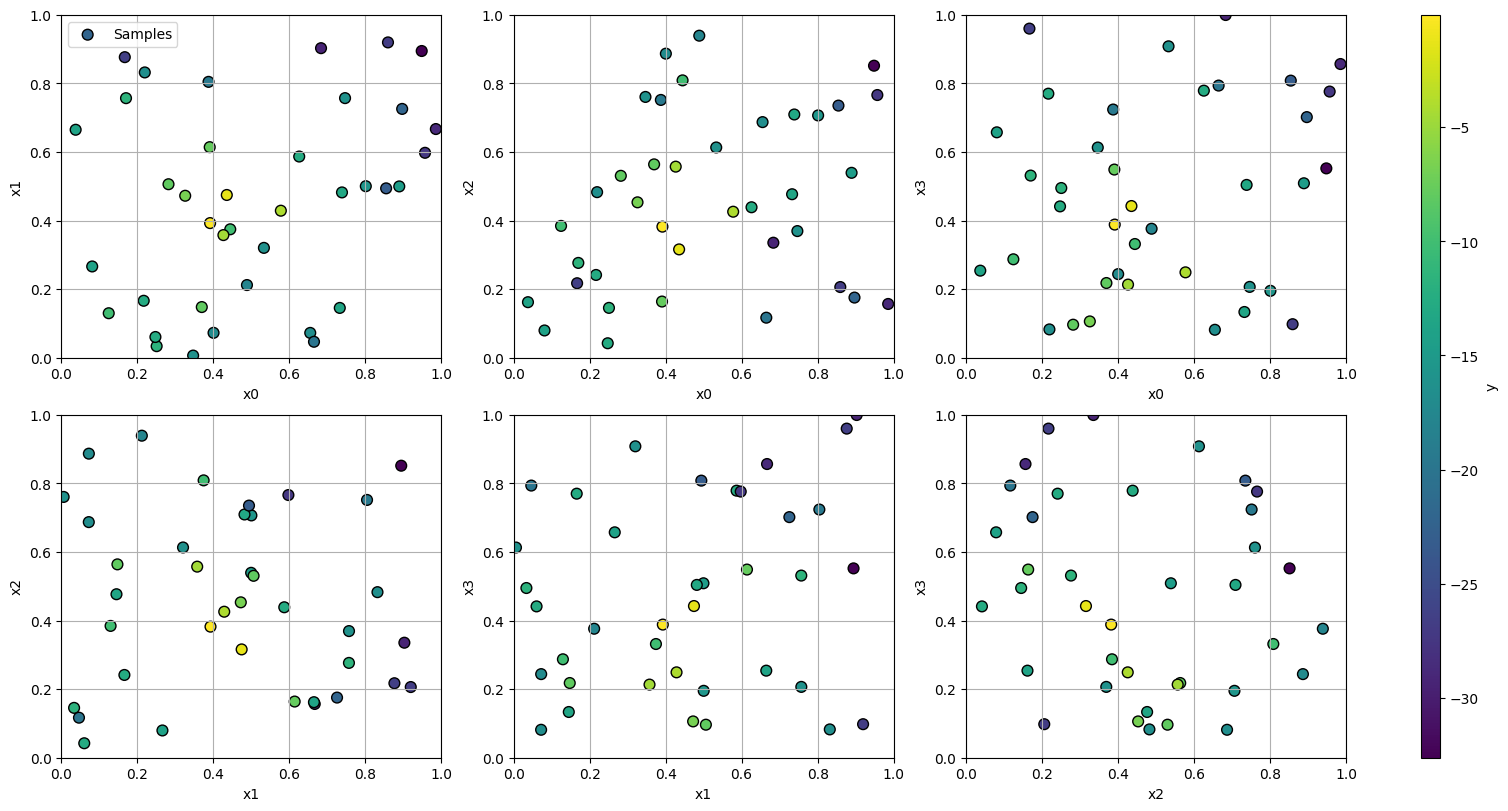

In [45]:
fig, axs = plot_2d_array(X, y)

We are fairly confident that we have identified a promising region. As we expect other maxima, we should explore a bit more. There are a numnber of methods that we can employ. We can continue with Bayesian Optimisation and fit a Gaussian Process surrogate model to the data as we have done before. We can also try a neural network surrogate model and rather than use a grid search which is inefficient in higher dimensions, we can generate candidate points with the Latin Hypercube algorithm, which can provide better coverage of the domain with fewer samples. If we build an ensemble of neural networks, each with different randomised initial weights, and train them on the data we can determine the mean and standard deviation of these candidates, which can be fed into an acquisition function to rank them.

As we only have 38 data points, we should not choose a neural network layout with too many parameters as this may cause overfitting. Assuming that all neurons in one layer are connected to all neurons in the next layer, the number of weight parameters is the product of the number of neurons in each layer and the number of bias parameters is the number of neurons in the next layer. Therefore, a 4 -> 5 -> 1 network (i.e. 4 input neurons, one hidden layer of 5 neurons and 1 output neuron) would have (4 x 5) weights + 5 biases + (5 x 1) weights + 1 bias = 25 + 6 = 31 parameters. This is approaching the number of data points we have.

However, simpler networks may struggle to capture the complicated relationships in the data, and therefore they would be prone to underfitting. There needs to be a balance.

We also need to decide on an activation function. Both the Tanh and Rectified Linear Unit (ReLU) activation functions are possible candidates. The Tanh activation function should produce smoother approximations than the ReLU activation function.

We can test a few layouts by splitting the data into training and validation data sets, and comparing the decays in the loss function with epoch as we train using the training set. We can use the Root Mean Square Error (RMSE) as the scoring metric because it gives us values that are in the same units of the output, making them easily comparable.

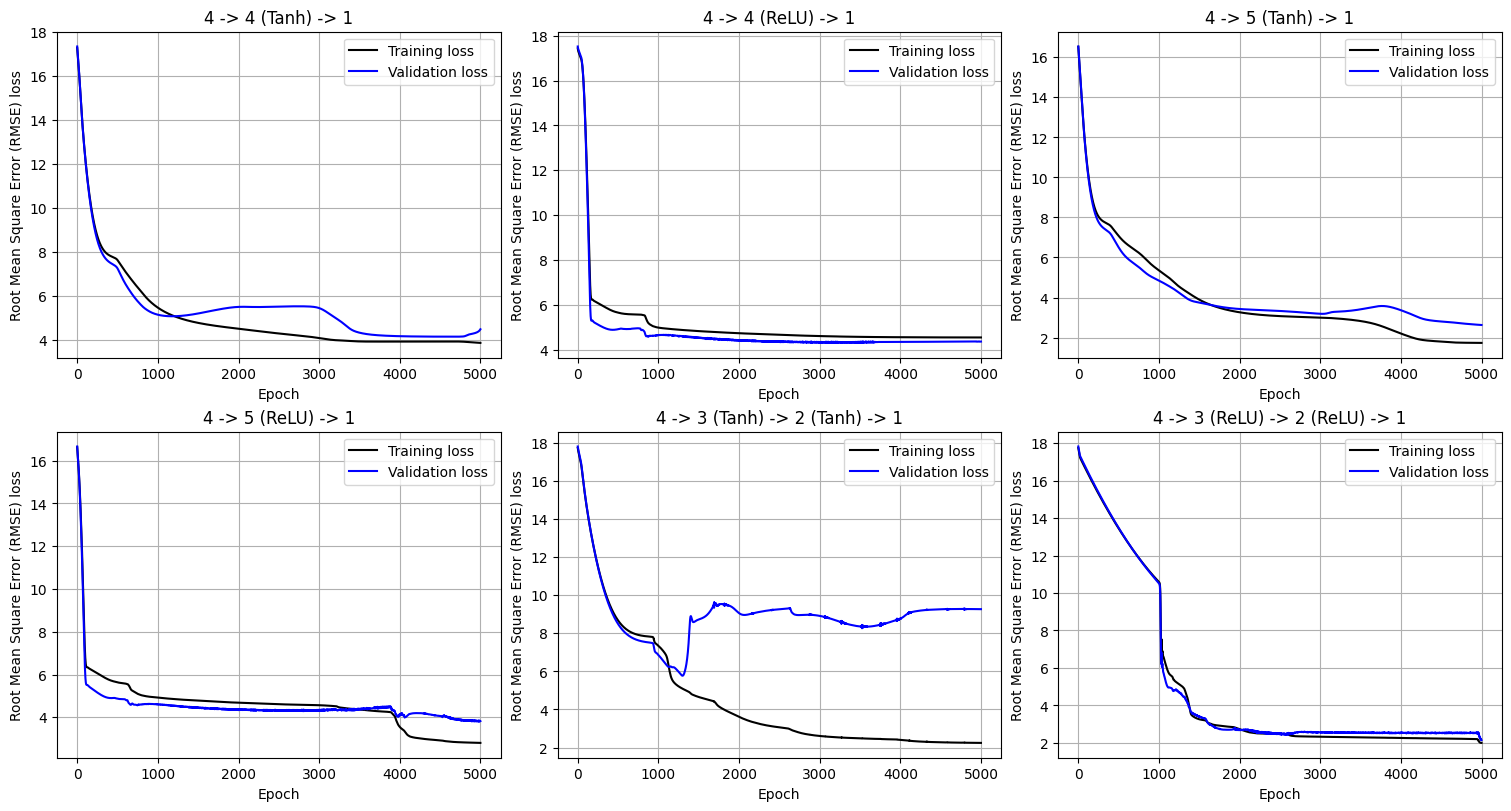

In [46]:
# Neural network models
nn_model_hyperparameters = {
    "4 -> 4 (Tanh) -> 1": {  # 20 + 5 = 25 parameters
        "neurons": [4],
        "activations": ["tanh"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 4 (ReLU) -> 1": {  # 20 + 5 = 25 parameters
        "neurons": [4],
        "activations": ["relu"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 5 (Tanh) -> 1": {  # 25 + 6 = 31 parameters
        "neurons": [5],
        "activations": ["tanh"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 5 (ReLU) -> 1": {  # 25 + 6 = 31 parameters
        "neurons": [5],
        "activations": ["relu"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 3 (Tanh) -> 2 (Tanh) -> 1": {  # 15 + 8 + 3 = 26 parameters
        "neurons": [3, 2],
        "activations": ["tanh", "tanh"],
        "learning_rate": 0.01,
        "weight_decay": 0.01
    },
    "4 -> 3 (ReLU) -> 2 (ReLU) -> 1": {  # 15 + 8 + 3 = 26 parameters
        "neurons": [3, 2],
        "activations": ["relu", "relu"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
}

X_train, X_validation, y_train, y_validation = train_test_split(
    X, y, test_size=0.2, random_state=create_rng_seed(seed_input)
)

fig, axs = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axs = np.atleast_1d(axs).ravel()
for i, (title, hyperparameters) in enumerate(nn_model_hyperparameters.items()):
    _, train_losses, val_losses = neural_networks.train_model(
        X_train,
        y_train,
        seed_input=seed_input,
        return_decay=True,
        epochs=5000,
        x_val=X_validation,
        y_val=y_validation,
        **hyperparameters,
    )

    plot_loss_function_decay_curves(train_losses, val_losses, title, ax=axs[i])

The models with a single hidden layer and Tanh activation function seem to perform quite well. Divergences between training and validation loss curves imply poor generalisation due to overfitting.

In the case of 4 -> 4 (Tanh) -> 1, the training and validation loss curves follow each other closely until around 1000 epochs, where the validation loss curve increases, stabilises, and then decreases back to the training loss curve before a small uptick at the end. This indicates that the model may be overfitting after 1000 epochs.

In the 4 -> 5 (Tanh) -> 1 layout, we see the training and validation loss curves diverging at around 3000 epochs. The validation curve recovers somewhat after 4000 epochs. Given that this layout gives us a lower RMSE estimate, we can try to train the ensemble of neural networks with this layout.

Firstly, to get an idea of how well the models perform, we should get an idea of the baseline RMSE, where the mean value is used as the predicted value for all data points:

In [47]:
baseline_rmse = get_baseline_rmse(y)
print(f"Baseline Root Mean Square Error (RMSE) = {baseline_rmse}")

Baseline Root Mean Square Error (RMSE) = 7.730332023369502


In [48]:
nn_model_layout = "4 -> 5 (Tanh) -> 1"
print(f"Neural network model layout: {nn_model_layout}:")
hyperparameters = nn_model_hyperparameters[nn_model_layout]
nn_rmse, nn_rmse_spread = neural_networks.loocv_score(
    X, y, seed_input=seed_input, **hyperparameters
)
print(f"RMSE = {nn_rmse}, RMSE spread = {nn_rmse_spread}, relative RMSE = {nn_rmse / (y.max() - y.min())}")

Neural network model layout: 4 -> 5 (Tanh) -> 1:
RMSE = 4.682522637811771, RMSE spread = 3.0069420138971346, relative RMSE = 0.14385585784947555


The baseline RMSE is around 25% of the range, which is quite high. Using Leave One Out Cross Validation, we obtain a slightly lower RMSE estimate, but it is arguable to claim that it is an improvement if we take errors into account.

We can train an emsemble of 20 neural networks on tne entire data set and calculate the mean predicted output and associated error for each observed data point:

In [49]:
# Train ensemble of 20 neural network models
nn_models = neural_networks.train_ensemble(
    X, y, seed_input=seed_input, **hyperparameters
)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Comparison of predicted output from 4 -> 5 (Tanh) -> 1 neural network ensemble and truth'}, xlabel='Sample', ylabel='Output'>)

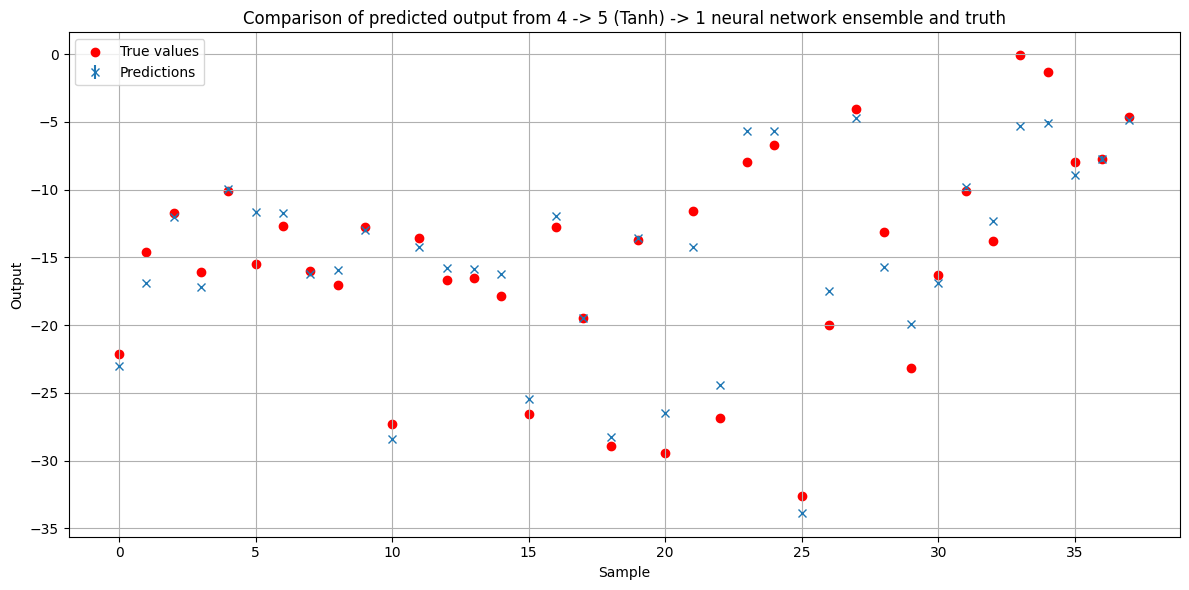

In [50]:
plot_nn_predictions(
    x_samples=X,
    y_samples=y,
    models=nn_models,
    title=f"Comparison of predicted output from {nn_model_layout} neural network ensemble and truth",
)

The standard deviations, reflected by the sizes of the error bars, are very small indicating that there is good agreement among the models.

The models struggle to predict the output of the two samples with the highest output, implying that there is a shared bias across the models. This could be because the layout of one hidden layer with 5 neurons is too simple to model the underlying function at high output values. However, introducing more neurons will increase the number of parameters and hence the risk of overfitting. In other words, increasing the number of parameters will result in the model memorising the data, having a negative effect on its ability to generalise.

In [51]:
# Get ensemble model's prediction for best observed data point
x_best = X[np.argmax(y)]
best_point_mean, best_point_std = neural_networks.ensemble_predict(nn_models, x_best)
print(f"Ensemble prediction for best observed data point = {best_point_mean} +/- {best_point_std/np.sqrt(len(nn_models))}\n")

# Generate candidates and select the one that maximises the UCB acquisition
# function (k = 1.96)
x_next = neural_networks.propose_point(
    models=nn_models,
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    acq_func=acquisition.ucb,
    k=1.96,
)
print(f"Proposed point from neural network ensemble model and UCB acquisition function (k = 1.96) = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")

x_next_mean, x_next_std = neural_networks.ensemble_predict(nn_models, x_next)
print(f"Ensemble prediction for proposed point = {x_next_mean} +/- {x_next_std/np.sqrt(len(nn_models))}")

Ensemble prediction for best observed data point = [-5.2662287] +/- [0.07734514]

Proposed point from neural network ensemble model and UCB acquisition function (k = 1.96) = [0.22125037 0.47692154 0.9163922  0.09210763]
Distance of proposed point from nearest neighbour = 0.35959270238045554
Ensemble prediction for proposed point = [-3.6486862] +/- [0.11420419]


As shown above, the neural network ensemble model's prediction for the best point is not consistent within errors with the true value. The Upper Confidence Bound (UCB) acquisition function proposes a point that lies significantly far away from any observed data points, so may be worth investigating as we trying to find any other promising areas. The predicted mean is higher than that predicted for the best observed data point.

Before we do this, we should also take a look at one of the other layouts. As mentioned before, it appears as though the 4 -> 5 (Tanh) -> 1 layout may be too simple to model the underlying function at high output values. Rather than increase the number of neurons in the fist hidden layer, we can increase the number of layers. The training and validation loss curves for the 4 -> 3 (ReLU) -> 2 (ReLU) -> 1 layout seem to line up very well implying good generalisation, and the RMSE is reasonably low after 5000 epochs.

We can use Leave One Out Cross Validation to get an idea of how the RMSE compares with the baseline:

In [52]:
nn_model_layout = "4 -> 3 (ReLU) -> 2 (ReLU) -> 1"
print(f"Neural network model layout: {nn_model_layout}:")
hyperparameters = nn_model_hyperparameters[nn_model_layout]
nn_rmse, nn_rmse_spread = neural_networks.loocv_score(
    X, y, seed_input=seed_input, **hyperparameters
)
print(f"RMSE = {nn_rmse}, RMSE spread = {nn_rmse_spread}, relative RMSE = {nn_rmse / (y.max() - y.min())}")

Neural network model layout: 4 -> 3 (ReLU) -> 2 (ReLU) -> 1:
RMSE = 6.486017067882779, RMSE spread = 3.4405690135944114, relative RMSE = 0.19926258162473068


The ensemble model's RMSE within errors is no better than the baseline RMSE. In fact, given the large standard deviation, it could be worse. We can still try to train an ensemble of neural network models on the data using this layout:

In [53]:
# Train ensemble of 20 neural network models
nn_models = neural_networks.train_ensemble(
    X, y, seed_input=seed_input, **hyperparameters
)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Comparison of predicted output from 4 -> 3 (ReLU) -> 2 (ReLU) -> 1 neural network ensemble and truth'}, xlabel='Sample', ylabel='Output'>)

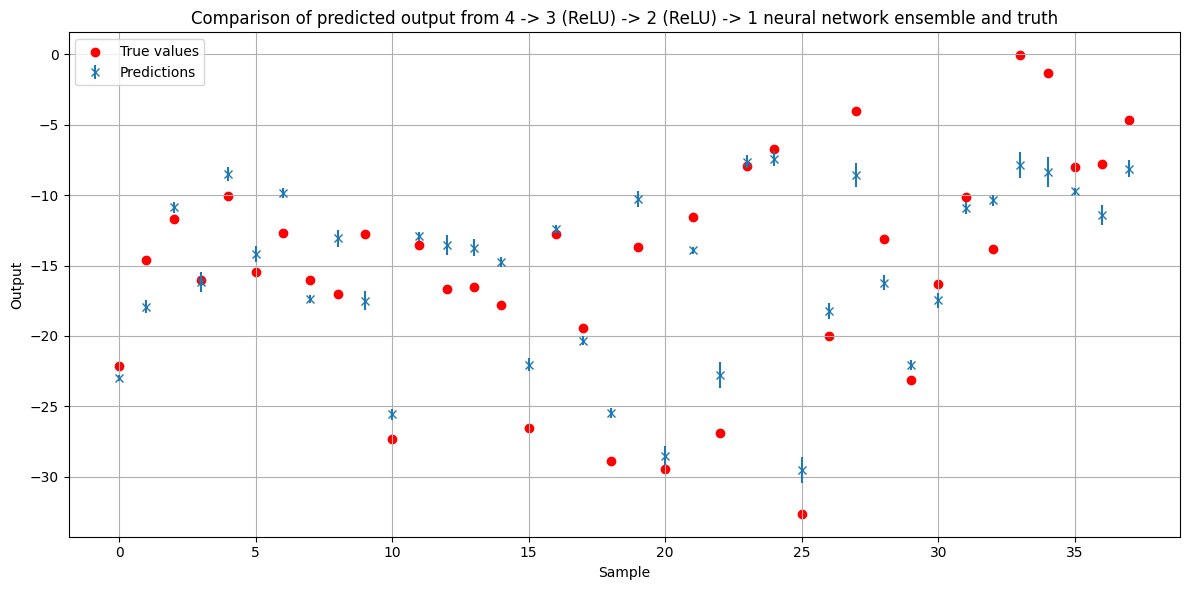

In [54]:
plot_nn_predictions(
    x_samples=X,
    y_samples=y,
    models=nn_models,
    title=f"Comparison of predicted output from {nn_model_layout} neural network ensemble and truth",
)

Compared with the 4 -> 5 (Tanh) -> 1 layout, there is less agreement among the models that form this ensemble, as evidenced by the larger error bars in the plot above. Additionally, the ensemble is unable to model the underlying function at high output values.

Therefore, the point suggested by the 4 -> 5 (Tanh) -> 1 neural network ensemble model should form this week's query. Unfortunately, I did not specify a random seed during the original analysis when constructing the ensemble and it therefore suggested a different point to query: (0.276065, 0.47989, 0.829594, 0.19214). Given that we expect many maxima, the fact that a different point was suggested should not be an issue, especially given that this ensemble yielded a similar RMSE and was unable to model the high output points.

## Week 10 - Investigating instability in neural network models

In [55]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import torch

from bbo import neural_networks
from bbo.data import get_current_weeks_points
from bbo.plotting import (
    plot_2d_array,
    plot_loss_function_decay_curves,
    plot_nn_predictions,
)
from bbo.random import create_rng_seed
from bbo.stats import get_baseline_rmse, get_rmse

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

# Neural network models
nn_model_hyperparameters = {
    "4 -> 4 (Tanh) -> 1": {
        "neurons": [4],
        "activations": ["tanh"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 4 (ReLU) -> 1": {
        "neurons": [4],
        "activations": ["relu"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 5 (Tanh) -> 1": {
        "neurons": [5],
        "activations": ["tanh"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 5 (ReLU) -> 1": {
        "neurons": [5],
        "activations": ["relu"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 3 (Tanh) -> 2 (Tanh) -> 1": {
        "neurons": [3, 2],
        "activations": ["tanh", "tanh"],
        "learning_rate": 0.01,
        "weight_decay": 0.01
    },
    "4 -> 3 (ReLU) -> 2 (ReLU) -> 1": {
        "neurons": [3, 2],
        "activations": ["relu", "relu"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
}

In [56]:
X, y = get_current_weeks_points(function_id=4, week=10)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.276065 0.47989  0.829594 0.19214 ] yields -13.970076423345137


Clearly we have not found a promising region with last week's query. Given that the neural network ensemble model was unable to predict the large output values, it is not too surprising that the neural network ensemble model does a poor job suggesting points to explore. This may be because there are simply not enough data points to construct a neural network that can model high output regions in the underlying function.

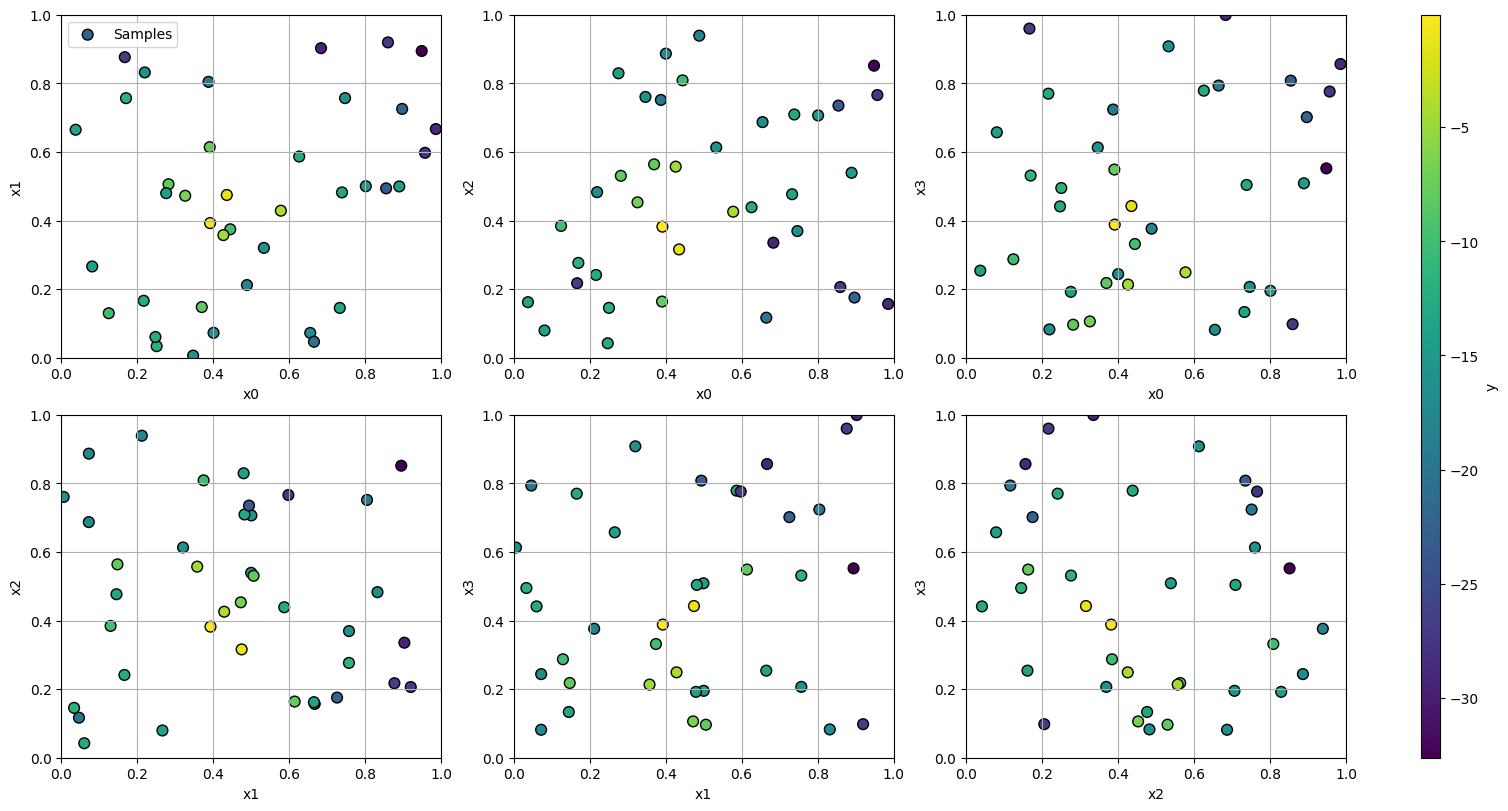

In [57]:
fig, axs = plot_2d_array(X, y)

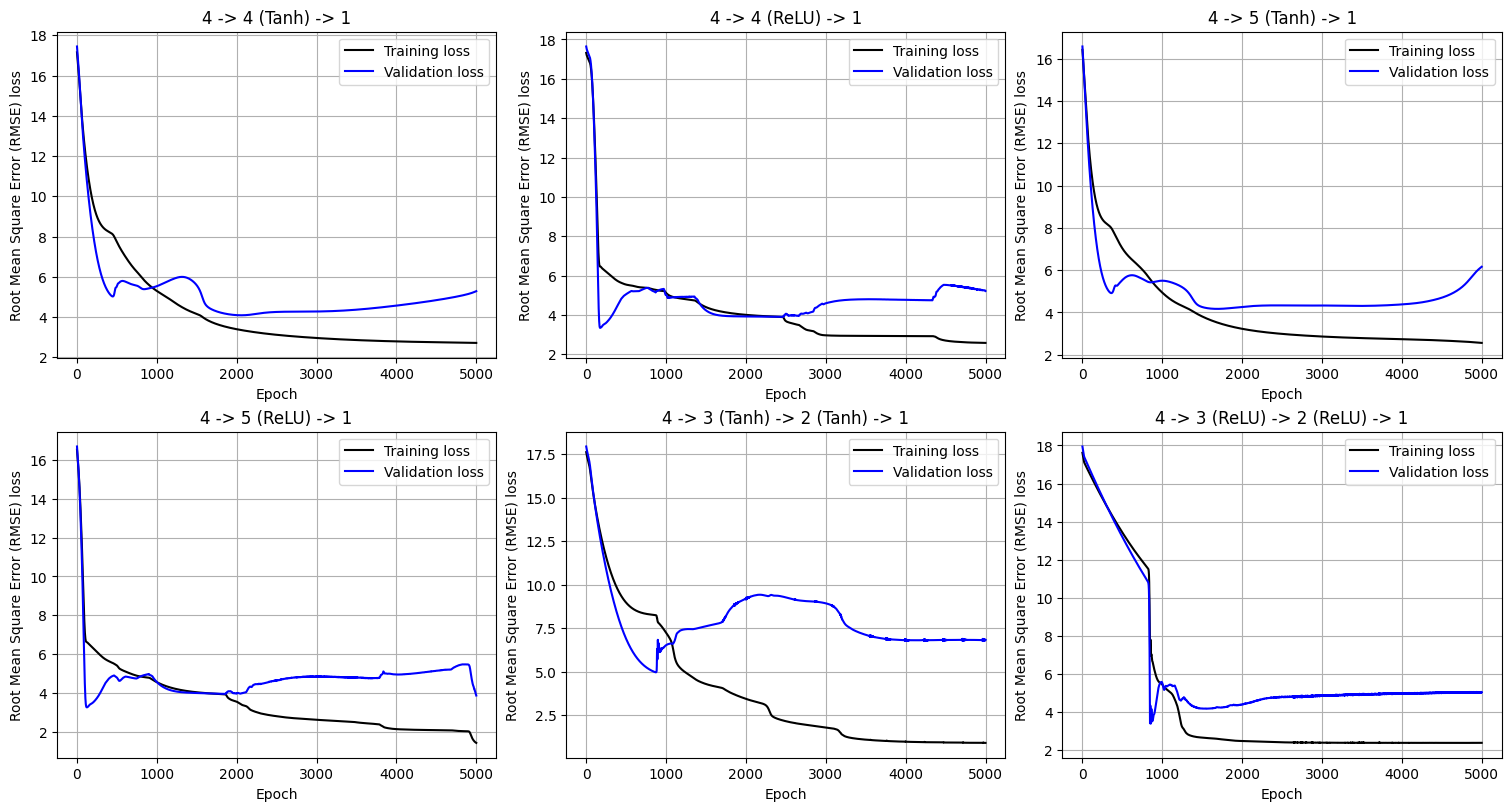

In [58]:
# Split data into training and validations sets to investigate performances
# of neural network models
X_train, X_validation, y_train, y_validation = train_test_split(
    X, y, test_size=0.2, random_state=create_rng_seed(seed_input)
)

fig, axs = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axs = np.atleast_1d(axs).ravel()
for i, (title, hyperparameters) in enumerate(nn_model_hyperparameters.items()):
    _, train_losses, val_losses = neural_networks.train_model(
        X_train,
        y_train,
        seed_input=seed_input,
        return_decay=True,
        epochs=5000,
        x_val=X_validation,
        y_val=y_validation,
        **hyperparameters,
    )

    plot_loss_function_decay_curves(train_losses, val_losses, title, ax=axs[i])

After splitting the data into training and validation sets, we compare the training loss curves to the validation loss curves above. Unlike last week, none of the validation loss curves seem to follow the training loss curves, implying that generalisation is poor among all the models. The neural network models with 4 neurons in a single hidden layer are not expected to have enough parameters to model the high output regions. The neural network layouts of 4 -> 5 (ReLU) -> 1 and 4 -> 5 (Tanh) -> 1 could be worth investigating. As we have investigated the latter last week, let's investigate the configuration with a Rectified Linear Unit (ReLU) activation function:

In [59]:
baseline_rmse = get_baseline_rmse(y)
print(f"Baseline Root Mean Square Error (RMSE) = {baseline_rmse}")

Baseline Root Mean Square Error (RMSE) = 7.63322653847429


In [60]:
nn_model_layout = "4 -> 5 (ReLU) -> 1"
print(f"Neural network model layout: {nn_model_layout}:")
hyperparameters = nn_model_hyperparameters[nn_model_layout]
nn_rmse, nn_rmse_spread = neural_networks.loocv_score(
    X, y, seed_input=seed_input, **hyperparameters
)
print(f"RMSE = {nn_rmse}, RMSE spread = {nn_rmse_spread}, relative RMSE = {nn_rmse / (y.max() - y.min())}")

Neural network model layout: 4 -> 5 (ReLU) -> 1:
RMSE = 4.9786379845817414, RMSE spread = 3.06278572022421, relative RMSE = 0.15295307542361114


The neural network ensemble model's Root Mean Square Error (RMSE) indicates that it is unlikely to perform better than the baseline model of assuming that the predicted value of all data points is the mean of the true outputs. We can see this below when we train an ensemble of 20 models and compare their predicted outputs to the true values:

In [61]:
# Train ensemble of 20 neural network models
nn_models = neural_networks.train_ensemble(
    X, y, seed_input=seed_input, **hyperparameters
)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Comparison of predicted output from 4 -> 5 (ReLU) -> 1 neural network ensemble and truth'}, xlabel='Sample', ylabel='Output'>)

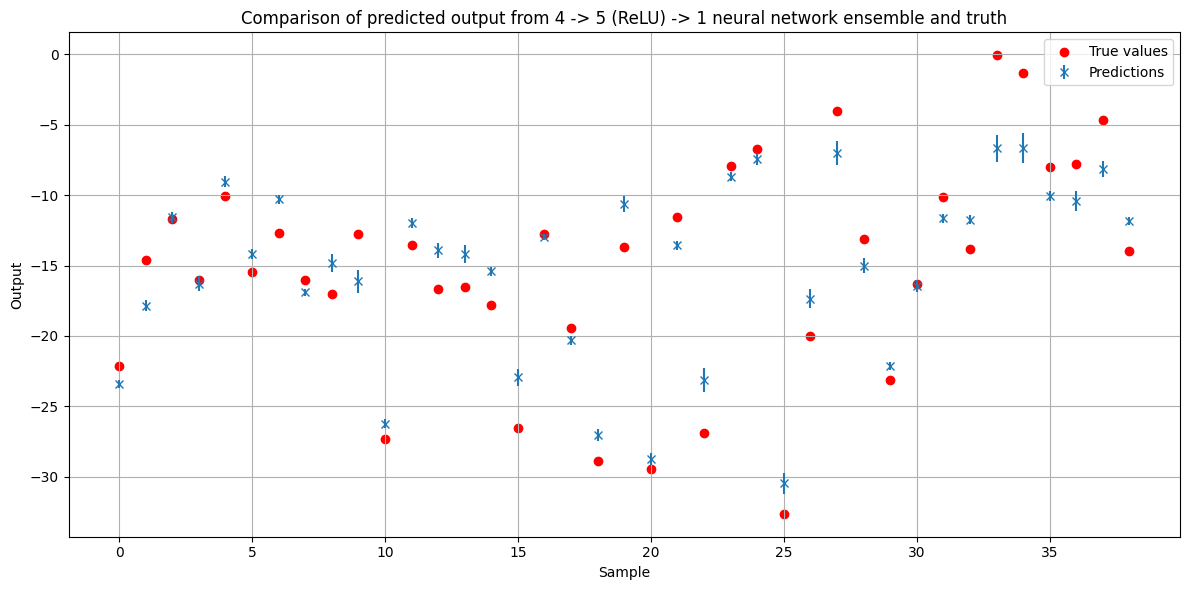

In [62]:
plot_nn_predictions(
    x_samples=X,
    y_samples=y,
    models=nn_models,
    title=f"Comparison of predicted output from {nn_model_layout} neural network ensemble and truth",
)

The relatively large error bars indicate that there is disagreement between the models. Additionally, the ensemble does not do a good job predicting the output for high output data points. We cna take a look a the summary statistics for predicted outputs from each model for the best observed point to get an understanding of the spread:

In [63]:
x_best = X[np.argmax(y)]

# Get predicted output for best point from each neural network model that forms
# ensemble
x_t = torch.tensor(x_best, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    preds = [model(x_t).item() for model in nn_models]
preds = np.array(preds)

print("Summary statistics for predicted outputs for best observed point:")
print(f"Mean = {preds.mean()}")
print(f"Standard deviation = {preds.std()}")

print(f"Minimum = {preds.min()}")
quantiles = [0.25, 0.5, 0.75]
for quantile in quantiles:
    print(f"{quantile * 100}% quantile = {np.quantile(preds, quantile)}")
print(f"Maximum = {preds.max()}\n")

best_point_mean, best_point_std = neural_networks.ensemble_predict(nn_models, x_best)
print(f"Ensemble prediction for best observed data point = {best_point_mean} +/- {best_point_std/np.sqrt(len(nn_models))}")

Summary statistics for predicted outputs for best observed point:
Mean = -6.675198432803154
Standard deviation = 4.284087896642433
Minimum = -12.53884506225586
25.0% quantile = -10.545851707458496
50.0% quantile = -5.729887008666992
75.0% quantile = -3.0950692892074585
Maximum = -0.8196988105773926

Ensemble prediction for best observed data point = [-6.675199] +/- [0.95795123]


Interestingly, while the ensemble does a poor job predicting the high value outputs, at least one of the models comes quite close (as indicated by the maximum value above). This is likely due to a favourable random initialisation of model parameters as opposed to being a genuine representation of the underlying function. Hence, it should be treated with caution. We can take a closer look at this particular model to see how well it predicts the data points:

Root Mean Square Error (RMSE) of max model = 0.9806175796887461


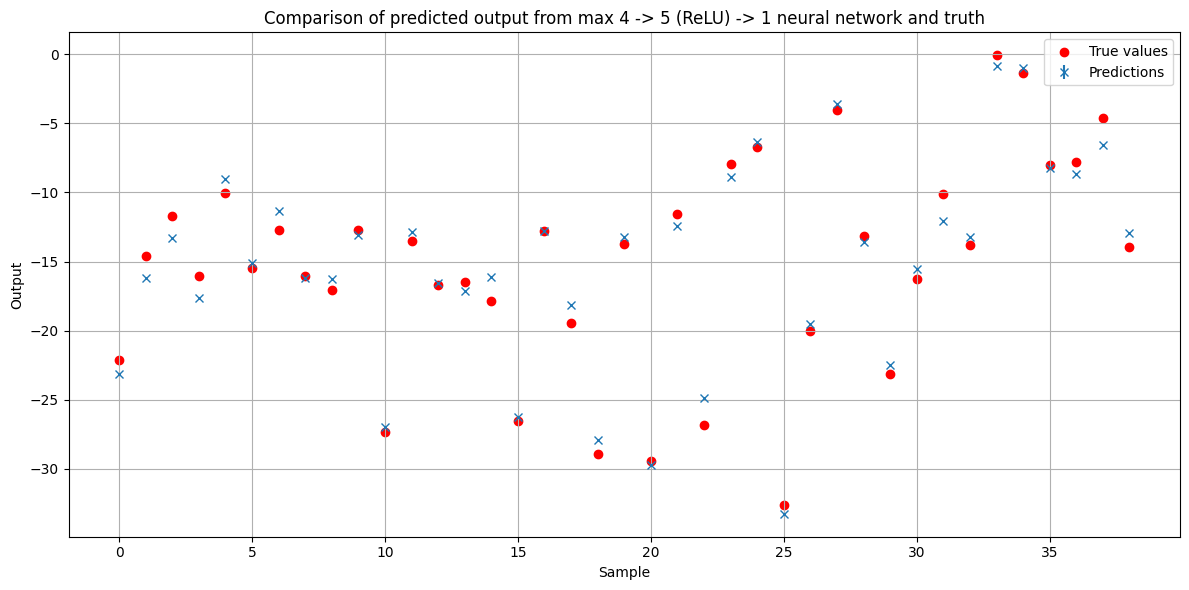

In [64]:
max_model_idx = np.argmax(preds)
plot_nn_predictions(
    x_samples=X,
    y_samples=y,
    models=[nn_models[max_model_idx]],
    title=f"Comparison of predicted output from max {nn_model_layout} neural network and truth",
)

mean_max_model, _ = neural_networks.ensemble_predict([nn_models[max_model_idx]], X)
rmse_max_model = get_rmse(y, mean_max_model)
print(f"Root Mean Square Error (RMSE) of max model = {rmse_max_model}")

It does a pretty good job. The large discrepancy between this model's predictions and those of the ensemble implies that there is significant uncertainty, and therefore neither should be trusted. The RMSE for this model is far lower than the baseline, and the plot above indicates that it comes pretty close. We can try to use this model to propose a new point to query, knowing full well that we cannot fully trust it. This makes this a high-risk, high-reward strategy.

As we are only using one model rather than an ensemble, we do not have a way to estimate the uncertainty for the acquisition function. Therefore, we can define the acquisition function as the predicted value, which we can seek to maximise.

In [65]:
# Generate candidates and select one with maximum mean prediction from 
max_model_idx = np.argmax(preds)
x_next = neural_networks.propose_point(
    models=[nn_models[max_model_idx]],
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    acq_func=lambda mean, std, **kwargs: mean,
    n_candidates=2000,
)
print(f"Proposed point from neural network model and highest mean acquisition function = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}\n")

x_next_t = torch.tensor(x_next, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    x_next_pred = nn_models[max_model_idx](x_next_t).item()
print(f"Predictions for proposed point from best performing model = {x_next_pred}\n")
x_next_mean, x_next_std = neural_networks.ensemble_predict(nn_models, x_next)
print(f"Ensemble prediction for proposed point = {x_next_mean} +/- {x_next_std/np.sqrt(len(nn_models))}")

Proposed point from neural network model and highest mean acquisition function = [0.52984369 0.42132337 0.20120058 0.31899593]
Distance of proposed point from nearest neighbour = 0.20028822111946618

Predictions for proposed point from best performing model = 0.9083760976791382

Ensemble prediction for proposed point = [-5.258657] +/- [1.09821706]


In my original analysis I did not set the random seed when assessing and training the neural network models, and therefore my results were different to those shown above. As with this analysis, I used the best performing model with the same layout (5 neurons in a single hidden layer, ReLU activation function), which proposed the point (0.141233, 0.46576, 0.388062, 0.530873). The predicted output was -0.1688 and the point was a Euclidean distance of 0.297 from its nearest neighbour. This point was selected for the next query for the same reasons given above.

It is not surprising that the submitted point and the proposed point above are so different as there are very few data points and therefore, there is very high uncertainty. A neural network is not a suitable model to use here. We are just implementing it as a learning exercise and to see if we can identify any other potential high output regions.

## Week 11 - Searching for new maxima

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import torch

from bbo import neural_networks
from bbo.data import get_current_weeks_points
from bbo.plotting import (
    plot_2d_array,
    plot_loss_function_decay_curves,
    plot_nn_predictions,
)
from bbo.random import create_rng_seed
from bbo.stats import get_baseline_rmse, get_rmse

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

# Neural network models
nn_model_hyperparameters = {
    "4 -> 4 (Tanh) -> 1": {
        "neurons": [4],
        "activations": ["tanh"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 4 (ReLU) -> 1": {
        "neurons": [4],
        "activations": ["relu"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 5 (Tanh) -> 1": {
        "neurons": [5],
        "activations": ["tanh"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 5 (ReLU) -> 1": {
        "neurons": [5],
        "activations": ["relu"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 3 (Tanh) -> 2 (Tanh) -> 1": {
        "neurons": [3, 2],
        "activations": ["tanh", "tanh"],
        "learning_rate": 0.01,
        "weight_decay": 0.01
    },
    "4 -> 3 (ReLU) -> 2 (ReLU) -> 1": {
        "neurons": [3, 2],
        "activations": ["relu", "relu"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
}

In [67]:
X, y = get_current_weeks_points(function_id=4, week=11)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.141233 0.46576  0.388062 0.530873] yields -6.196329014084405


Last week's query yields a relatively poor output with little indication that there is a peak in this region. A neural network is very much like a black box, so the reasons why the model may have thought that this area was promising are not easy to extract from the model.

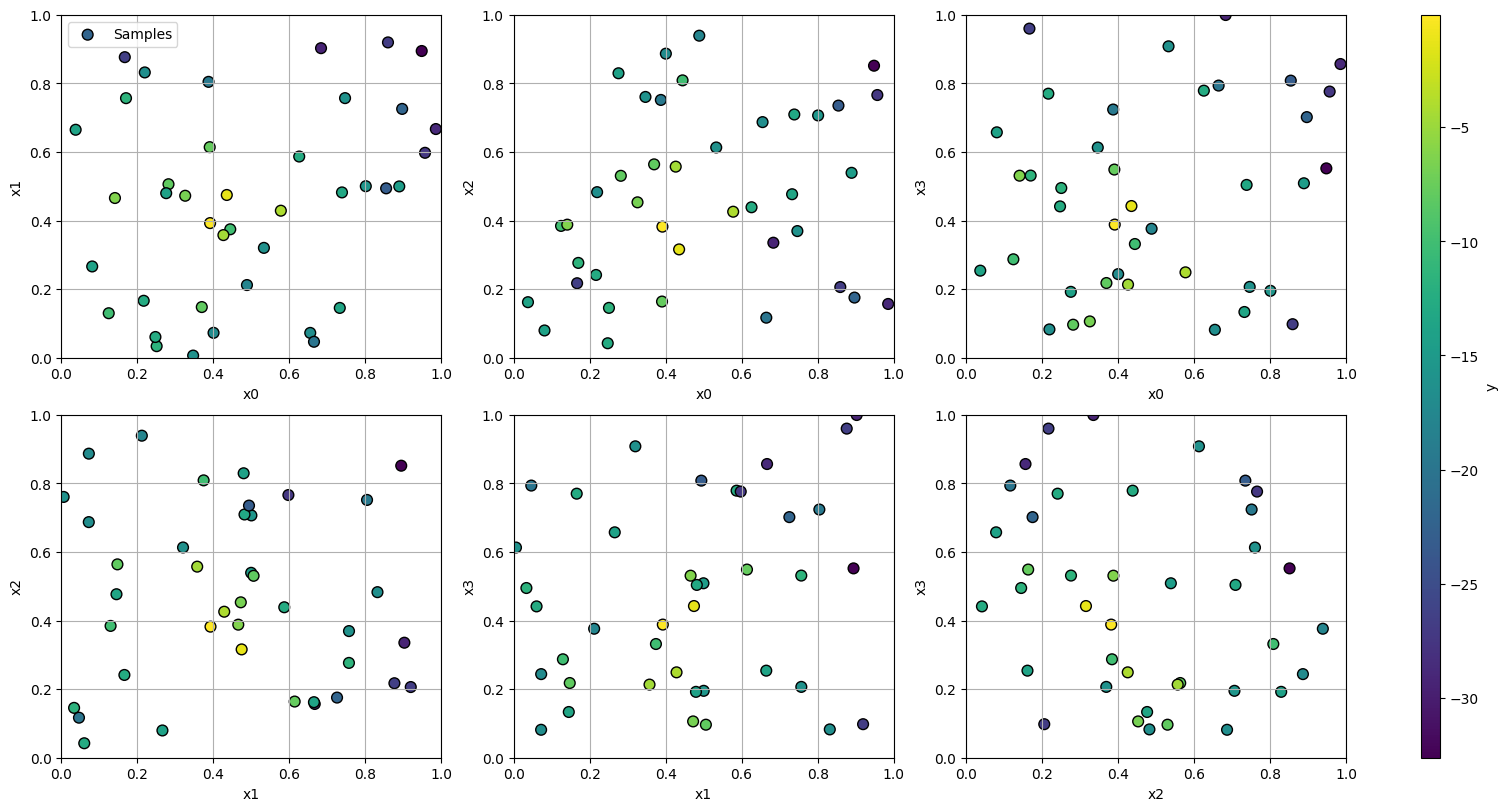

In [68]:
fig, axs = plot_2d_array(X, y)

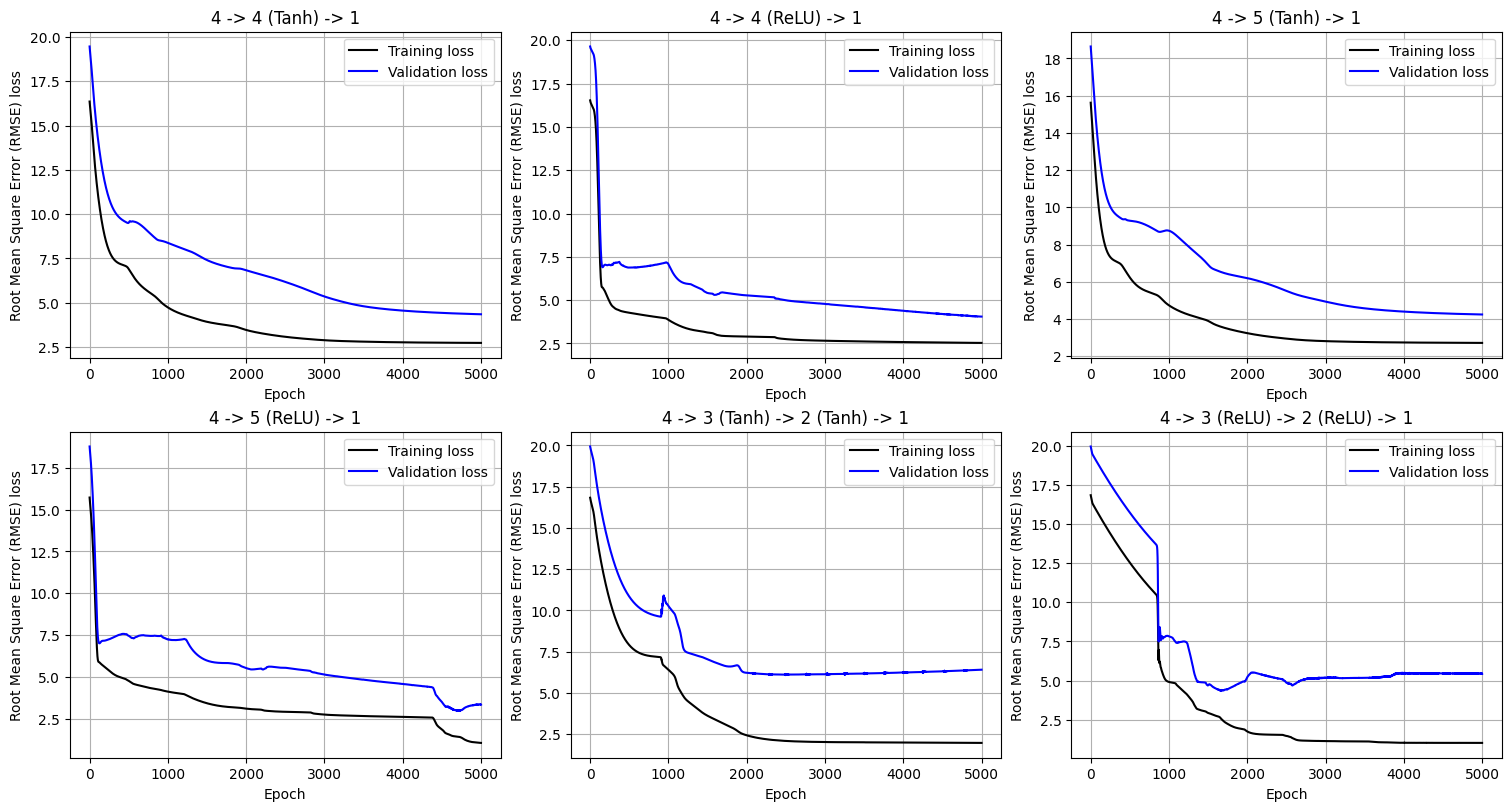

In [69]:
# Split data into training and validations sets to investigate performances
# of neural network models
X_train, X_validation, y_train, y_validation = train_test_split(
    X, y, test_size=0.2, random_state=create_rng_seed(seed_input)
)

fig, axs = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axs = np.atleast_1d(axs).ravel()
for i, (title, hyperparameters) in enumerate(nn_model_hyperparameters.items()):
    _, train_losses, val_losses = neural_networks.train_model(
        X_train,
        y_train,
        seed_input=seed_input,
        return_decay=True,
        epochs=5000,
        x_val=X_validation,
        y_val=y_validation,
        **hyperparameters,
    )

    plot_loss_function_decay_curves(train_losses, val_losses, title, ax=axs[i])

In every layout, the training and validation loss curves diverge indicating that the ensemble models generalise poorly.

In [70]:
baseline_rmse = get_baseline_rmse(y)
print(f"Baseline Root Mean Square Error (RMSE) = {baseline_rmse}")

Baseline Root Mean Square Error (RMSE) = 7.667417248309718


In [71]:
nn_model_layout = "4 -> 5 (ReLU) -> 1"
print(f"Neural network model layout: {nn_model_layout}:")
hyperparameters = nn_model_hyperparameters[nn_model_layout]
nn_rmse, nn_rmse_spread = neural_networks.loocv_score(
    X, y, seed_input=seed_input, **hyperparameters
)
print(f"RMSE = {nn_rmse}, RMSE spread = {nn_rmse_spread}, relative RMSE = {nn_rmse / (y.max() - y.min())}")

Neural network model layout: 4 -> 5 (ReLU) -> 1:
RMSE = 4.554057830607582, RMSE spread = 2.929781631002848, relative RMSE = 0.13990917857565952


While the spread in the Root Mean Square Error (RMSE) is lower, the RMSE of the 4 -> 5 (ReLU) -> 1 neural network ensemble model is still quite high.

In [72]:
# Train ensemble of 20 neural network models
nn_models = neural_networks.train_ensemble(
    X, y, seed_input=seed_input, **hyperparameters
)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Comparison of predicted output from 4 -> 5 (ReLU) -> 1 neural network ensemble and truth'}, xlabel='Sample', ylabel='Output'>)

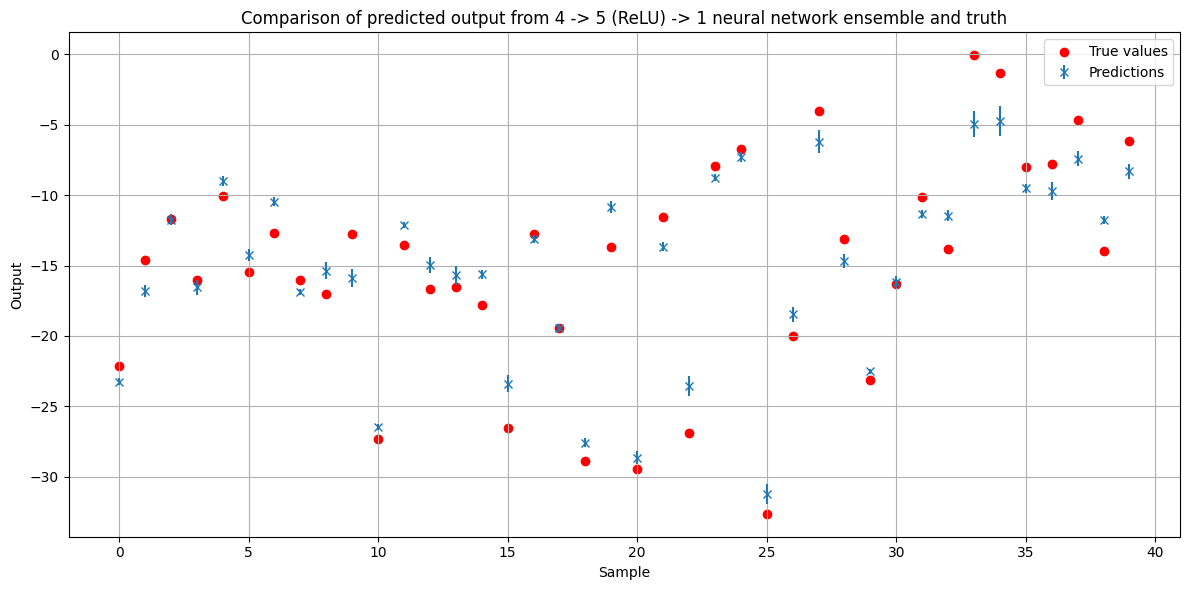

In [73]:
plot_nn_predictions(
    x_samples=X,
    y_samples=y,
    models=nn_models,
    title=f"Comparison of predicted output from {nn_model_layout} neural network ensemble and truth",
)

The ensemble model does a slightly better job of predicting the output of the best points than it has done in the past.

In [74]:
x_best = X[np.argmax(y)]

# Get predicted output for best point from each neural network model that forms
# ensemble
x_t = torch.tensor(x_best, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    preds = [model(x_t).item() for model in nn_models]
preds = np.array(preds)

print("Summary statistics for predicted outputs for best observed point:")
print(f"Mean = {preds.mean()}")
print(f"Standard deviation = {preds.std()}")

print(f"Minimum = {preds.min()}")
quantiles = [0.25, 0.5, 0.75]
for quantile in quantiles:
    print(f"{quantile * 100}% quantile = {np.quantile(preds, quantile)}")
print(f"Maximum = {preds.max()}\n")

best_point_mean, best_point_std = neural_networks.ensemble_predict(nn_models, x_best)
print(f"Ensemble prediction for best observed data point = {best_point_mean} +/- {best_point_std/np.sqrt(len(nn_models))}")

Summary statistics for predicted outputs for best observed point:
Mean = -4.953113883733749
Standard deviation = 4.131388569170032
Minimum = -12.341700553894043
25.0% quantile = -6.569161534309387
50.0% quantile = -3.0930739641189575
75.0% quantile = -1.6328475177288055
Maximum = -1.037961483001709

Ensemble prediction for best observed data point = [-4.953114] +/- [0.92380659]


When we look at the summary statistics for the best observed point, we see that the range has barely moved. In other words there is still a large disagreement between models. However, on closer inspection, the median value lies higher than it did before. The mean has also increased. Therefore, while the range of predictions may be much the same as it was last week, the majority of predictions appear to be higher rather than lower.

However, the large discrepancy between the ensemble prediction for the best observed data point and the prediction from the best model indicates that there is significant uncertainty, making any predictions from this model quite unreliable.

We can take a look at the predictions from the model that comes closest to predicting the output of the best data point:

Root Mean Square Error (RMSE) of max model = 0.9514946383760103


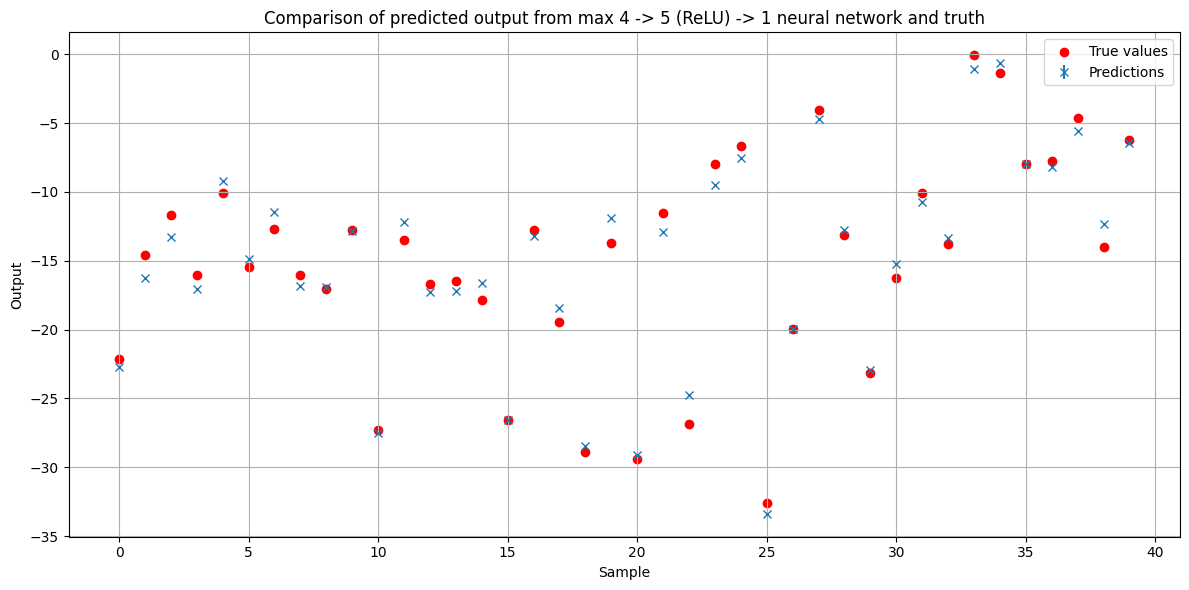

In [75]:
max_model_idx = np.argmax(preds)
plot_nn_predictions(
    x_samples=X,
    y_samples=y,
    models=[nn_models[max_model_idx]],
    title=f"Comparison of predicted output from max {nn_model_layout} neural network and truth",
)

mean_max_model, _ = neural_networks.ensemble_predict([nn_models[max_model_idx]], X)
rmse_max_model = get_rmse(y, mean_max_model)
print(f"Root Mean Square Error (RMSE) of max model = {rmse_max_model}")

Again, it does a pretty good job, capturing the high output data points and the general trend quite well. This is reflected in the low RMSE. However, this is likely a result of overfitting rather than evidence of the model's predictive accuracy.

As with last week, we can use the predicted output from this model to propose a new point:

In [76]:
# Generate candidates and select one with maximum mean prediction from 
max_model_idx = np.argmax(preds)
x_next = neural_networks.propose_point(
    models=[nn_models[max_model_idx]],
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    acq_func=lambda mean, std, **kwargs: mean,
    n_candidates=2000,
)
print(f"Proposed point from neural network model and highest mean acquisition function = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}\n")

x_next_t = torch.tensor(x_next, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    x_next_pred = nn_models[max_model_idx](x_next_t).item()
print(f"Predictions for proposed point from best performing model = {x_next_pred}\n")
x_next_mean, x_next_std = neural_networks.ensemble_predict(nn_models, x_next)
print(f"Ensemble prediction for proposed point = {x_next_mean} +/- {x_next_std/np.sqrt(len(nn_models))}")

Proposed point from neural network model and highest mean acquisition function = [0.52984369 0.42132337 0.20120058 0.31899593]
Distance of proposed point from nearest neighbour = 0.20028822111946618

Predictions for proposed point from best performing model = -0.6459915041923523

Ensemble prediction for proposed point = [-3.8480015] +/- [1.05367903]


The proposed point is the same as that suggested last week. This is not too suprising as this point has not been queried, and given the random seed has not changed, it would appear as though last week's query has had little effect on the model in this region.

Again, in my original analysis I did not set the random seed when assessing and training the neural network models, and therefore my results were different to those shown above. As with this analysis, I used the best performing model with the same layout (5 neurons in a single hidden layer, ReLU activation function), which proposed the point (0.470686, 0.43102, 0.189768, 0.396384). The predicted output was -0.4483 and the point was a Euclidean distance of 0.145 from its nearest neighbour.

The point submitted in this week's query lies much closer to the proposed point above. It will be interesting to see whether the results will change the model's predictions in this region.

## Week 12 - Final attempt to find another promising region

In [77]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import torch

from bbo import neural_networks
from bbo.data import get_current_weeks_points
from bbo.plotting import (
    plot_2d_array,
    plot_loss_function_decay_curves,
    plot_nn_predictions,
)
from bbo.random import create_rng_seed
from bbo.stats import get_baseline_rmse, get_rmse

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

# Neural network models
nn_model_hyperparameters = {
    "4 -> 4 (Tanh) -> 1": {
        "neurons": [4],
        "activations": ["tanh"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 4 (ReLU) -> 1": {
        "neurons": [4],
        "activations": ["relu"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 5 (Tanh) -> 1": {
        "neurons": [5],
        "activations": ["tanh"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 5 (ReLU) -> 1": {
        "neurons": [5],
        "activations": ["relu"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
    "4 -> 3 (Tanh) -> 2 (Tanh) -> 1": {
        "neurons": [3, 2],
        "activations": ["tanh", "tanh"],
        "learning_rate": 0.01,
        "weight_decay": 0.01
    },
    "4 -> 3 (ReLU) -> 2 (ReLU) -> 1": {
        "neurons": [3, 2],
        "activations": ["relu", "relu"],
        "learning_rate": 0.01,
        "weight_decay": 0.01,
    },
}

In [78]:
X, y = get_current_weeks_points(function_id=4, week=12)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.470686 0.43102  0.189768 0.396384] yields -4.069743118274101


A bit of a better output from last week's query, but it is still not close to the output of the highest observed data points. While last week's query is not the same point as that suggested above, it is in the same region and would indicate that this region is not promising.

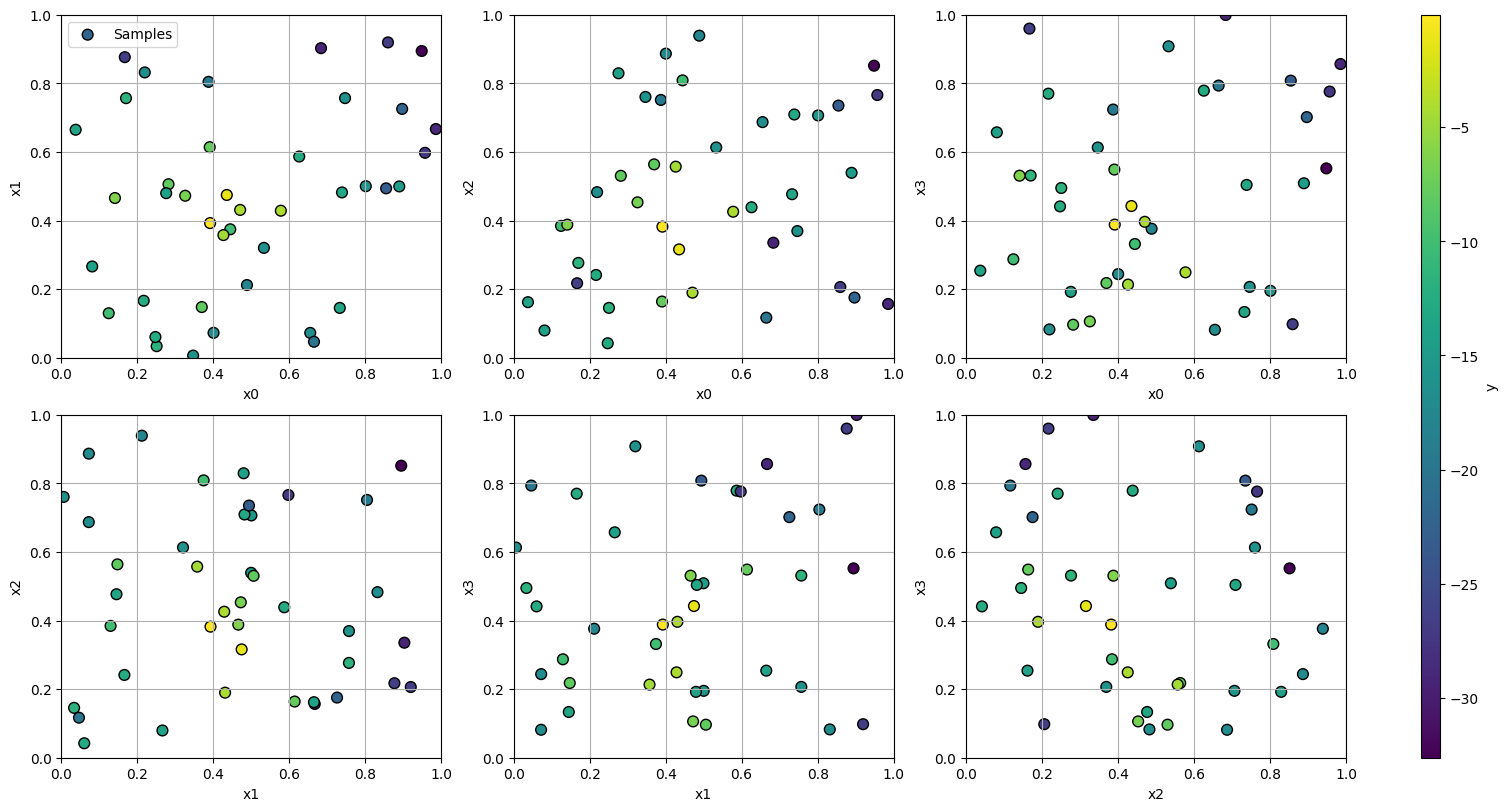

In [79]:
fig, axs = plot_2d_array(X, y)

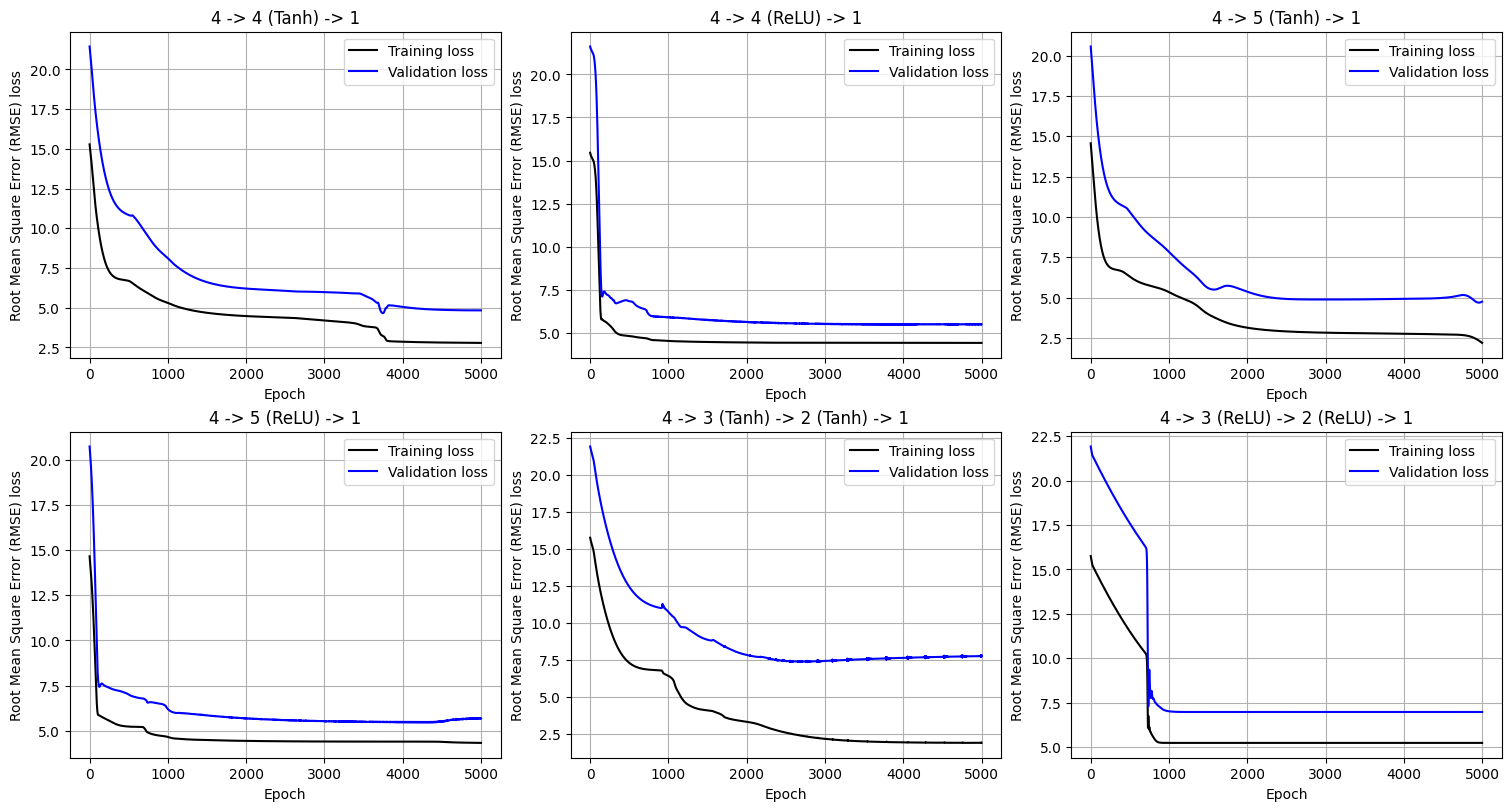

In [80]:
# Split data into training and validations sets to investigate performances
# of neural network models
X_train, X_validation, y_train, y_validation = train_test_split(
    X, y, test_size=0.2, random_state=create_rng_seed(seed_input)
)

fig, axs = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axs = np.atleast_1d(axs).ravel()
for i, (title, hyperparameters) in enumerate(nn_model_hyperparameters.items()):
    _, train_losses, val_losses = neural_networks.train_model(
        X_train,
        y_train,
        seed_input=seed_input,
        return_decay=True,
        epochs=5000,
        x_val=X_validation,
        y_val=y_validation,
        **hyperparameters,
    )

    plot_loss_function_decay_curves(train_losses, val_losses, title, ax=axs[i])

We have the luxury of giving the neural network surrogate model one more try before we go back to probing around the maximum we previously identified. The training and validation loss curves for the 4 -> 5 (ReLU) -> 1 output are quite similar. We can perform Leave One Out Cross Validation on this layout to get an idea of the Root Mean Square Error (RMSE):

In [81]:
baseline_rmse = get_baseline_rmse(y)
print(f"Baseline Root Mean Square Error (RMSE) = {baseline_rmse}")

Baseline Root Mean Square Error (RMSE) = 7.758195535801424


In [82]:
nn_model_layout = "4 -> 5 (ReLU) -> 1"
print(f"Neural network model layout: {nn_model_layout}:")
hyperparameters = nn_model_hyperparameters[nn_model_layout]
nn_rmse, nn_rmse_spread = neural_networks.loocv_score(
    X, y, seed_input=seed_input, **hyperparameters
)
print(f"RMSE = {nn_rmse}, RMSE spread = {nn_rmse_spread}, relative RMSE = {nn_rmse / (y.max() - y.min())}")

Neural network model layout: 4 -> 5 (ReLU) -> 1:
RMSE = 4.112666697620456, RMSE spread = 2.5869465253022934, relative RMSE = 0.126348816994004


Again, the RMSE from cross validation barely beats the baseline RMSE when we take errors into account. We can train the usual ensemble of 20 neural network models and take a look at the predictions for the observed data points:

In [83]:
# Train ensemble of 20 neural network models
nn_models = neural_networks.train_ensemble(
    X, y, seed_input=seed_input, **hyperparameters
)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Comparison of predicted output from 4 -> 5 (ReLU) -> 1 neural network ensemble and truth'}, xlabel='Sample', ylabel='Output'>)

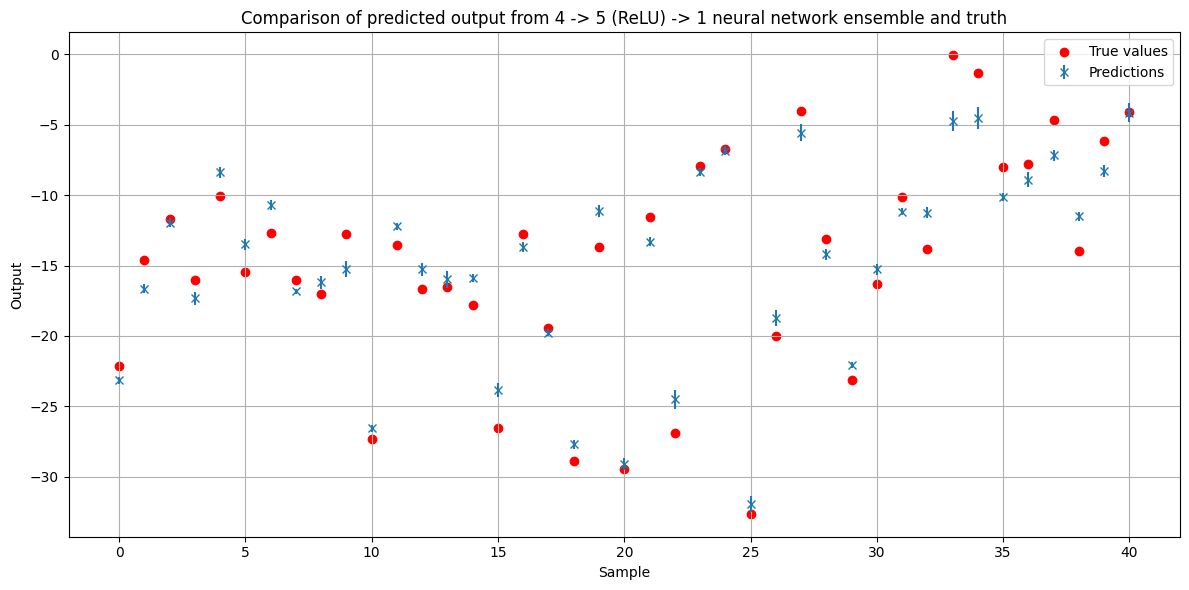

In [84]:
plot_nn_predictions(
    x_samples=X,
    y_samples=y,
    models=nn_models,
    title=f"Comparison of predicted output from {nn_model_layout} neural network ensemble and truth",
)

In [85]:
x_best = X[np.argmax(y)]

# Get predicted output for best point from each neural network model that forms
# ensemble
x_t = torch.tensor(x_best, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    preds = [model(x_t).item() for model in nn_models]
preds = np.array(preds)

print("Summary statistics for predicted outputs for best observed point:")
print(f"Mean = {preds.mean()}")
print(f"Standard deviation = {preds.std()}")

print(f"Minimum = {preds.min()}")
quantiles = [0.25, 0.5, 0.75]
for quantile in quantiles:
    print(f"{quantile * 100}% quantile = {np.quantile(preds, quantile)}")
print(f"Maximum = {preds.max()}\n")

best_point_mean, best_point_std = neural_networks.ensemble_predict(nn_models, x_best)
print(f"Ensemble prediction for best observed data point = {best_point_mean} +/- {best_point_std/np.sqrt(len(nn_models))}")

Summary statistics for predicted outputs for best observed point:
Mean = -4.754277038574219
Standard deviation = 3.0921447571504705
Minimum = -12.02954387664795
25.0% quantile = -5.813472151756287
50.0% quantile = -3.6470835208892822
75.0% quantile = -2.4790642857551575
Maximum = -1.359839916229248

Ensemble prediction for best observed data point = [-4.754277] +/- [0.69142458]


The ensemble prediction lies within errors of that from last week, so it is not possible to call this an improvement. Additionally, the median is lower than it was last week, implying that there are fewer models predicting relatively high outputs for the best observed data points. The maximum prediction has dropped as well. We can take a closer look at the model that gets closest to predicting the output of the best observed point:

Root Mean Square Error (RMSE) of max model = 1.129062782066485


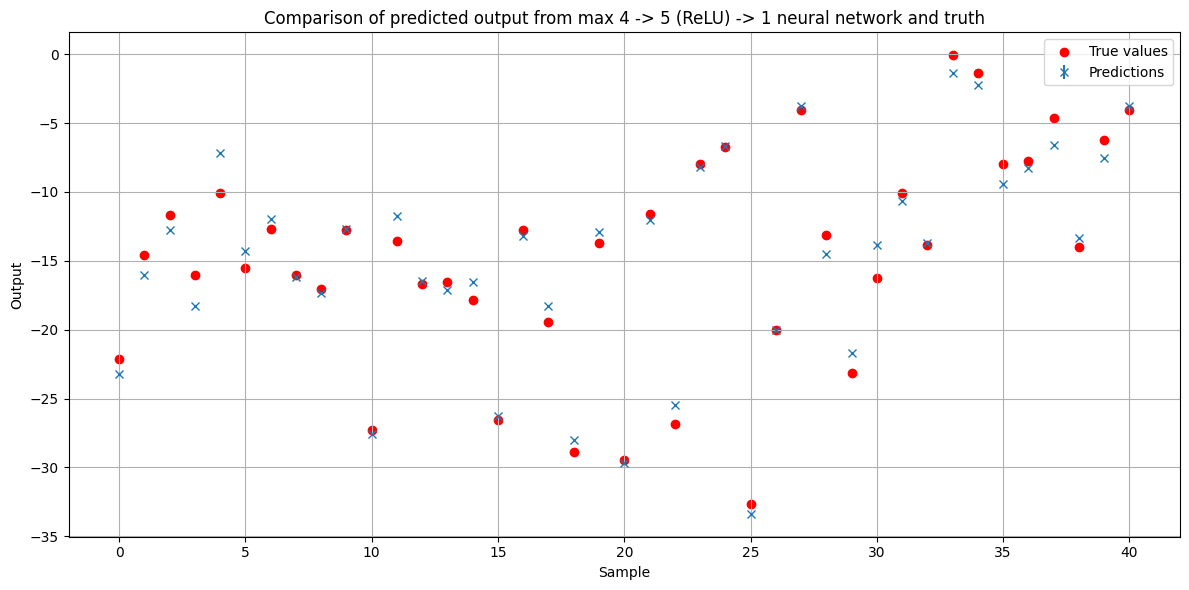

In [86]:
max_model_idx = np.argmax(preds)
plot_nn_predictions(
    x_samples=X,
    y_samples=y,
    models=[nn_models[max_model_idx]],
    title=f"Comparison of predicted output from max {nn_model_layout} neural network and truth",
)

mean_max_model, _ = neural_networks.ensemble_predict([nn_models[max_model_idx]], X)
rmse_max_model = get_rmse(y, mean_max_model)
print(f"Root Mean Square Error (RMSE) of max model = {rmse_max_model}")

The RMSE of this model, while still small, is larger than last week. We can see what point it proposes:

In [87]:
# Generate candidates and select one with maximum mean prediction from 
max_model_idx = np.argmax(preds)
x_next = neural_networks.propose_point(
    models=[nn_models[max_model_idx]],
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    acq_func=lambda mean, std, **kwargs: mean,
    n_candidates=2000,
)
print(f"Proposed point from neural network model and highest mean acquisition function = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}\n")

x_next_t = torch.tensor(x_next, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    x_next_pred = nn_models[max_model_idx](x_next_t).item()
print(f"Predictions for proposed point from best performing model = {x_next_pred}\n")
x_next_mean, x_next_std = neural_networks.ensemble_predict(nn_models, x_next)
print(f"Ensemble prediction for proposed point = {x_next_mean} +/- {x_next_std/np.sqrt(len(nn_models))}")

Proposed point from neural network model and highest mean acquisition function = [0.49822392 0.36804638 0.25388528 0.25004265]
Distance of proposed point from nearest neighbour = 0.17392765459794912

Predictions for proposed point from best performing model = -1.6031756401062012

Ensemble prediction for proposed point = [-3.7587059] +/- [0.67207109]


The output from last week's query has changed the proposed point. We can make a final exploratory query using this model before returning to the quadratic linear regression model next week. We know that the data set is too small for neural networks, and promising regions that the model identifies are those that are undersampled and hence predictions in these regions are unreliable.

In my original analysis I did not set the random seed when assessing and training the neural network models, and therefore my results were different to those shown above. As with this analysis, I used the best performing model with the same layout (5 neurons in a single hidden layer, ReLU activation function), which proposed the point (0.519956, 0.430761, 0.183121, 0.210050). The predicted output was -1.0262 and the point was a Euclidean distance of 0.193 from its nearest neighbour.

The point submitted in this week's query lies reasonably close to the proposed point above.

## Week 13 - A return to linear regression

In [88]:
import numpy as np

from bbo.data import get_current_weeks_points
from bbo.linear_regression import (
    get_lr_models,
    kfoldcv,
    loocv,
    get_hessian_matrix_and_gradient_vector,
)
from bbo.plotting import plot_2d_array
from bbo.stats import get_baseline_rmse

seed_input = "function 4"  # input string to create random seed
n_dimensions = 4  # number of features
grd_res = 21  # axis resolution

In [89]:
X, y = get_current_weeks_points(function_id=4, week=13)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.519956 0.430761 0.183121 0.21005 ] yields -6.076270769814595


Last week's query does not reveal a promising area. Our experiment with neural network models did not reveal any new promising regions to explore.

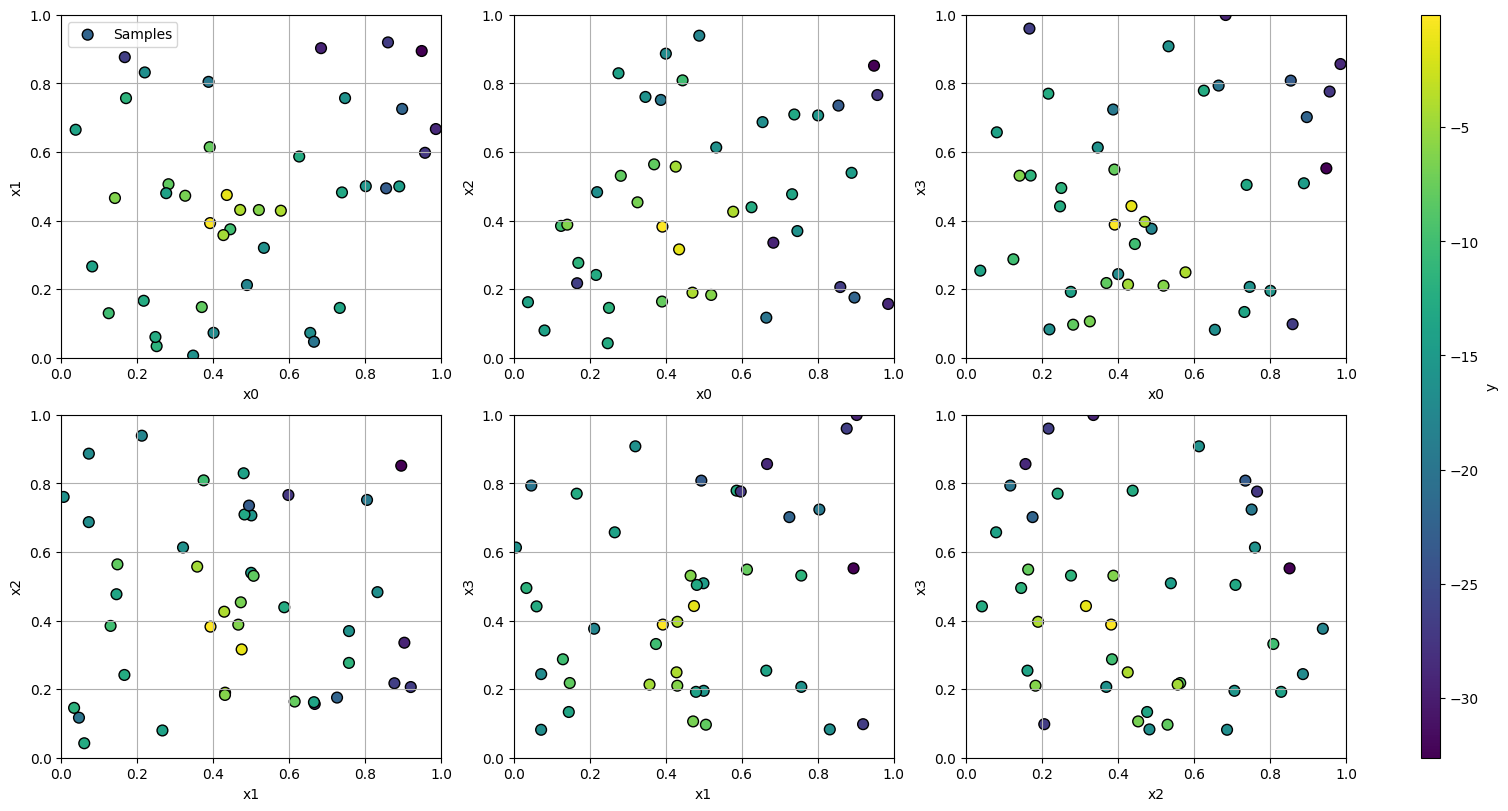

In [90]:
fig, axs = plot_2d_array(X, y)

We can go back to the global linear regression model we were using earlier and see whether it still fits the data well:

In [91]:
print(f"Baseline RMSE = {get_baseline_rmse(y)}")

cv_methods = {
    "Leave One Out Cross Validation": loocv(X, y),
    "10-Fold Cross Validation": kfoldcv(X, y, seed_input=seed_input, n_splits=10),
}
for method, scores in cv_methods.items():
    print(f"\n{method}")
    for name, stats in scores.items():
        print(f"{name} model: RMSE = {stats['RMSE']}, RMSE spread = {stats['RMSE spread']}, relative RMSE = {stats['relative RMSE']}")

Baseline RMSE = 7.777655753894996

Leave One Out Cross Validation
linear model: RMSE = 6.248754900665168, RMSE spread = 3.373808855560958, relative RMSE = 0.19197344385854032
quadratic model: RMSE = 1.1495988424540324, RMSE spread = 0.7414083163650995, relative RMSE = 0.03531782768727252
cubic model: RMSE = 8.039275609244587, RMSE spread = 6.029251431885946, relative RMSE = 0.24698159063181754

10-Fold Cross Validation
linear model: RMSE = 6.523302429175143, RMSE spread = 0.3746739597205599, relative RMSE = 0.20040805769581854
quadratic model: RMSE = 1.2166458278959713, RMSE spread = 0.26983713039926477, relative RMSE = 0.037377636545234336
cubic model: RMSE = 15.476023308379101, RMSE spread = 1.3594227710195208, relative RMSE = 0.47545239635312325


The Root Mean Square Error (RMSE) of the quadratic linear regression model is still quite low and significantly below that of the baseline. So, for our final query, let's find the peak suggested by this model:

In [92]:
lr_models = get_lr_models()
lr_model = lr_models["quadratic"]
lr_model.fit(X, y)

H, g = get_hessian_matrix_and_gradient_vector(
    model=lr_model, n_dimensions=n_dimensions
)

# Find stationary point (i.e. where gradient = 0)
x_next = -np.linalg.solve(H, g)
print(f"Proposed point as peak of quadratic linear regression model = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")
print(f"Distance of proposed point to best observed data point = {np.linalg.norm(x_next - X[np.argmax(y)])}")

Proposed point as peak of quadratic linear regression model = [0.40283481 0.39905457 0.37624761 0.3972769 ]
Distance of proposed point from nearest neighbour = 0.016858505708526945
Distance of proposed point to best observed data point = 0.016858505708526945


The proposed point is very close to the best observed data point. Querying it is a low-risk strategy, and it is the best chance we currently have to find a point with an output above the expensive baseline.

## Final Result

In [93]:
from bbo.data import get_current_weeks_points, get_final_maximum
from bbo.linear_regression import (
    get_lr_models,
    kfoldcv,
    loocv,
    get_hessian_matrix_and_gradient_vector,
)
from bbo.plotting import plot_2d_array

X, y = get_current_weeks_points(function_id=4, week=14)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.402835 0.399055 0.376248 0.397277] yields 0.19969510131872825


With our final query, we get a positive output and beat the expensive baseline. Therefore, this can be regarded as being a successful analysis.

In [94]:
print(f"Baseline RMSE = {get_baseline_rmse(y)}\n")

cv_methods = {
    "Leave One Out Cross Validation": loocv(X, y),
    "10-Fold Cross Validation": kfoldcv(X, y, seed_input=seed_input, n_splits=10),
}
for method, scores in cv_methods.items():
    print(f"{method}")
    for name, stats in scores.items():
        print(f"{name} model: RMSE = {stats['RMSE']}, RMSE spread = {stats['RMSE spread']}, relative RMSE = {stats['relative RMSE']}")
    print("")

lr_models = get_lr_models()
lr_model = lr_models["quadratic"]
lr_model.fit(X, y)

H, g = get_hessian_matrix_and_gradient_vector(
    model=lr_model, n_dimensions=n_dimensions
)

# Find stationary point (i.e. where gradient = 0)
x_next = -np.linalg.solve(H, g)
print(f"Proposed point as peak of quadratic linear regression model = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")

Baseline RMSE = 8.000066220031258

Leave One Out Cross Validation
linear model: RMSE = 6.491578947231945, RMSE spread = 3.518502628463129, relative RMSE = 0.1977611174193261
quadratic model: RMSE = 1.2704106909067632, RMSE spread = 0.8254243095779251, relative RMSE = 0.038702115441776944
cubic model: RMSE = 8.60035656019142, RMSE spread = 6.451292222860172, relative RMSE = 0.26200345668958197

10-Fold Cross Validation
linear model: RMSE = 6.832531707660057, RMSE spread = 0.21395749766461486, relative RMSE = 0.2081479893094413
quadratic model: RMSE = 1.3369602952157673, RMSE spread = 0.23463813178369045, relative RMSE = 0.04072949956803402
cubic model: RMSE = 18.170531829565924, RMSE spread = 1.560342246195679, relative RMSE = 0.5535517179916067

Proposed point as peak of quadratic linear regression model = [0.40482673 0.40031813 0.3779896  0.40066176]
Distance of proposed point from nearest neighbour = 0.004477976191886564


The quadratic linear regression model performs well. The Root Mean Square Error (RMSE) is still lower than that of the baseline, and has stayed consistently low. While the point proposed by the model lies very close to the current maximum, the peak seems quite steep and this may lead to a significant improvement. The model has realiably proposed points that have yielded a higher output than the current maximum.

It is still a bit puzzling why a global quadratic linear regression model seems to fit the data so well, especially given our expection that there should be many local maxima. The underlying function should be too complicated to be predicted with such a simple model, but it performs surprisingly well.

This is an example of where a simple model, such as linear regression, can outperform a complicated and less-interpretable model such as neural networks.

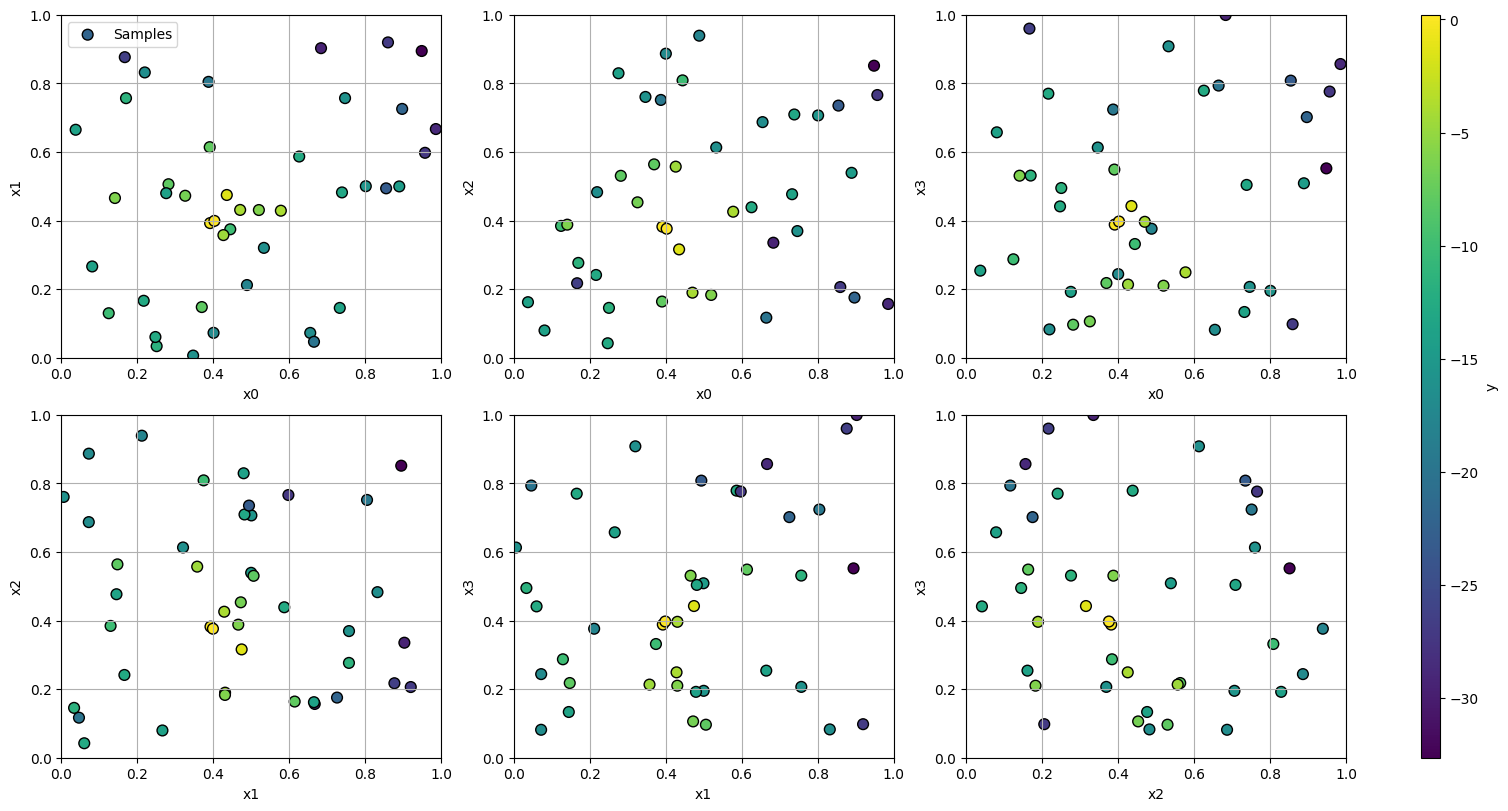

In [95]:
fig, axs = plot_2d_array(X, y)

From the final plots above, we can see that there is a third promising point that we previously had assumed was part of the main peak. However, if the peaks are very steep, this could very well be another promising region to explore. There are not enough data points to fit two local quadratic linear regression models so close to each other. However, we could use a global Gaussian Process surrogate model to investigate the region around this point and an exploitative acquisition function such as Probability of Improvement (PI) to find promising points to query.

In [96]:
X_best, y_best, y_improv = get_final_maximum(function_id=4)
print(f"The best observed point {X_best} yields an output of {y_best}, which is an absolute improvement of {y_improv} over the best point in the initial data set")

The best observed point [0.402835 0.399055 0.376248 0.397277] yields an output of 0.19969510131872825, which is an absolute improvement of 4.22523738322689 over the best point in the initial data set
